In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import Image as IPImage, display
from PIL import Image as PILImage

In [2]:
censo_estudio_ruta = r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\dataraw\censo_estudio.parquet"
censo_data = pd.read_parquet(censo_estudio_ruta)
censo_data.columns

Index(['p01_0', 'p02_1', 'idprov_2', 'nprov_3', 'redcoden_4', 'idpto_5',
       'ndpto_6', 'redcoden_7', 'idfrac_8', 'redcoden_9',
       ...
       'p30_10', 'descapor_11', 'p01_0_8', 'p02_1_8', 'p35_2', 'p36_3',
       'hnvua_4', 'edad_5', 'p33_6', 'letra_7'],
      dtype='object', length=104)

In [3]:
cols_a_borrar = ['p01_0_1','p01_0_2','p01_0_3','p01_0_4','p01_0_5','p01_0_6','p01_0_7','p01_0_8','p02_1_1','p02_1_2','p02_1_3','p02_1_4','p02_1_5','p02_1_6','p02_1_7','p02_1_8'] #Son todas columnas iguales a p01_0 y p02_1 pero están repetidas
censo_data = censo_data.drop(columns=cols_a_borrar)

In [4]:
censo_data.columns = (censo_data.columns.str.replace(r'_\d+$', '', regex=True)) #Me saco los sufijos "_2"  por ejemplo, de encima, para cada nombre de columna
columnas = censo_data.columns.tolist()

posiciones_redcoden = [i for i, col in enumerate(columnas) if col == "redcoden"]
nombres_redcoden = ["redcoden_prov","redcoden_dpto","redcoden_frac","redcoden_radio"]

for posicion, nombre in zip(posiciones_redcoden,nombres_redcoden):
    columnas[posicion] = nombre #cada uno de los 4 redcoden corresponde a prov, depto, etc. los nombro con la respectiva unidad geografica a la que hacen referencia

censo_data.columns = columnas
censo_data.columns

Index(['p01', 'p02', 'idprov', 'nprov', 'redcoden_prov', 'idpto', 'ndpto',
       'redcoden_dpto', 'idfrac', 'redcoden_frac', 'idradio', 'redcoden_radio',
       'tipovivg', 'v01', 'v01_ocup', 'v02', 'v04', 'v06', 'codgl', 'codloc',
       'codaglo', 'totpobv', 'tipo_radio', 'catgl', 'urp', 'nhogh', 'totpobh',
       'h10', 'h11_h12', 'inmat', 'h13', 'h14', 'h16', 'h18', 'h19', 'h20',
       'h20_hacina', 'h22', 'h23', 'h24a', 'h24b', 'h24c', 'nbi_hac',
       'nbi_viv', 'nbi_san', 'nbi_esc', 'nbi_sub', 'nbi_tot', 'tiphogar',
       'eduhog', 'hogmig', 'htotmig', 'h15_h17', 'h15_h17_h18', 'ipmh',
       'edad_edu', 'edadqui', 'edadgru', 'p06', 'p07', 'p08', 'p09', 'p10',
       'p11', 'p12', 'conasi', 'niv_asi', 'aesc', 'mni', 'p13', 'p14', 'p15',
       'p16', 'p17', 'p18', 'p19', 'p20', 'p21', 'condact', 'condactd', 'p30',
       'descapor', 'p35', 'p36', 'hnvua', 'edad', 'p33', 'letra'],
      dtype='object')

In [5]:
print(censo_data.shape)
print(censo_data.head(20))

(7663584, 88)
    p01  p02 idprov nprov  redcoden_prov idpto     ndpto  redcoden_dpto  \
0     1    2     02  Caba              2   007  Comuna 1           2007   
1     1    2     02  Caba              2   007  Comuna 1           2007   
2     1    2     02  Caba              2   007  Comuna 1           2007   
3     1    2     02  Caba              2   007  Comuna 1           2007   
4    10    2     02  Caba              2   007  Comuna 1           2007   
5     1    1     02  Caba              2   007  Comuna 1           2007   
6     3    2     02  Caba              2   007  Comuna 1           2007   
7     1    1     02  Caba              2   007  Comuna 1           2007   
8     2    2     02  Caba              2   007  Comuna 1           2007   
9     3    2     02  Caba              2   007  Comuna 1           2007   
10    3    1     02  Caba              2   007  Comuna 1           2007   
11    1    1     02  Caba              2   007  Comuna 1           2007   
12    1    

In [6]:
#Genero codigo de radio censal
censo_data["idprov"] = (censo_data["idprov"].astype(str).str.zfill(2))
censo_data["idpto"] = (censo_data["idpto"].astype(str).str.zfill(3))
censo_data["idfrac"] = (censo_data["idfrac"].astype(str).str.zfill(2))
censo_data["idradio"] = (censo_data["idradio"].astype(str).str.zfill(2))
censo_data["codigo"] = ( censo_data["idprov"] + censo_data["idpto"] + censo_data["idfrac"] + censo_data["idradio"]) #Creo el codigo identificador a nivel geografico en base a los 4 codigos geograficos anteriores 
                                                                                                                    #y en cómo está construido dicho codigo en el geojson
print(censo_data[["idprov","idpto","idfrac","idradio", "codigo"]].head(20))

   idprov idpto idfrac idradio     codigo
0      02   007     01      01  020070101
1      02   007     01      01  020070101
2      02   007     01      01  020070101
3      02   007     01      01  020070101
4      02   007     01      01  020070101
5      02   007     01      01  020070101
6      02   007     01      01  020070101
7      02   007     01      01  020070101
8      02   007     01      01  020070101
9      02   007     01      01  020070101
10     02   007     01      01  020070101
11     02   007     01      01  020070101
12     02   007     01      01  020070101
13     02   007     01      01  020070101
14     02   007     01      01  020070101
15     02   007     01      01  020070101
16     02   007     01      01  020070101
17     02   007     01      01  020070101
18     02   007     01      01  020070101
19     02   007     01      01  020070101


In [7]:
print(censo_data["mni"].value_counts().sort_index())

mni
1      621813
2      887022
3      687645
4     1391814
5     1359462
6      358600
7      511558
8      822836
9      657580
10     108835
11     205726
99      50693
Name: count, dtype: int64


In [8]:
#Criterio: uso MNI (Maximo Nivel de Instruccion).

def nse_mni(mni):

    if pd.isna(mni): return np.nan
    if mni == 99: return np.nan
    if mni in [1, 2]: return 1 #Sin Instruccion, Primario Incompleto -> Clase muy baja
    if mni in [3, 4]: return 2 #Primario Completo, Secundario Incompleto -> Clase Baja
    if mni in [5, 6, 7, 8]: return 3 #Secundario Completo, Terciario Completo o Incompleto, Universitario Incompleto -> Clase media
    if mni in [9, 10, 11]: return 4 #Universitario Completo, Posgrado Completo o Incompleto -> Clase Alta.

    return np.nan

censo_data["NSE"] = (censo_data["mni"].apply(nse_mni))
censo_data["NSE"].value_counts(dropna=False).sort_index()

NSE
1.0    1508835
2.0    2079459
3.0    3052456
4.0     972141
NaN      50693
Name: count, dtype: int64

In [9]:
jefes_hogar = censo_data.loc[censo_data["p01"] == 1].copy()
tabla_nse_jefes = pd.concat([jefes_hogar["NSE"].value_counts(dropna=False).sort_index().rename("cantidad"),
                            jefes_hogar["NSE"].value_counts(dropna=False,normalize=True).sort_index().round(2).rename("porcentaje")],axis=1)
print(tabla_nse_jefes) 

     cantidad  porcentaje
NSE                      
1.0    205168        0.07
2.0    758659        0.25
3.0   1439876        0.48
4.0    598775        0.20
NaN     27584        0.01


In [10]:
tabla_nse_radio = (jefes_hogar.groupby(["codigo", "NSE"],dropna=False).size().reset_index(name="hogares"))
print(tabla_nse_radio.head(20))

       codigo  NSE  hogares
0   020070101  1.0        9
1   020070101  2.0       22
2   020070101  3.0       53
3   020070101  4.0       19
4   020070101  NaN        3
5   020070201  1.0       25
6   020070201  2.0       99
7   020070201  3.0       91
8   020070201  4.0       16
9   020070202  1.0       29
10  020070202  2.0       89
11  020070202  3.0       51
12  020070202  NaN        1
13  020070203  1.0       15
14  020070203  2.0       35
15  020070203  3.0       50
16  020070203  4.0        1
17  020070203  NaN        1
18  020070204  1.0       21
19  020070204  2.0      101


In [11]:
nse_mayoritario = (tabla_nse_radio.sort_values(["codigo", "hogares"],ascending=[True, False]).drop_duplicates("codigo")[["codigo", "NSE"]].rename(columns={"NSE": "NSE_radio"})) 
#Al ordenar, dentro de cada radio censal, de mayor a menor el NSE segun cantidad de hogares, y luego quedarme con el primer registro por radio, me guarda el par (codigo, NSE mayoritario)

print(nse_mayoritario["NSE_radio"].value_counts())

NSE_radio
3.0    6554
2.0    1720
4.0     573
Name: count, dtype: int64


In [12]:
#Me quedo con la distribucion completa, por si la necesito despues
nse_pivot = tabla_nse_radio.pivot(index="codigo",columns="NSE",values="hogares").fillna(0)
print(nse_pivot.head(20))

NSE        NaN   1.0    2.0    3.0   4.0
codigo                                  
020070101  3.0   9.0   22.0   53.0  19.0
020070201  0.0  25.0   99.0   91.0  16.0
020070202  1.0  29.0   89.0   51.0   0.0
020070203  1.0  15.0   35.0   50.0   1.0
020070204  1.0  21.0  101.0   82.0   6.0
020070205  4.0  22.0  103.0   93.0   7.0
020070207  3.0  42.0  150.0  115.0   9.0
020070208  0.0  30.0  107.0  101.0  11.0
020070209  0.0  25.0   65.0   96.0   2.0
020070210  1.0  15.0   53.0   54.0   4.0
020070211  1.0  49.0   91.0   98.0  10.0
020070212  1.0  48.0  188.0  175.0  11.0
020070213  1.0  26.0   61.0   75.0   8.0
020070214  2.0  53.0   78.0   99.0  12.0
020070215  3.0  35.0  121.0  114.0   6.0
020070216  0.0  14.0   73.0   64.0   3.0
020070217  2.0  45.0  105.0  103.0   4.0
020070218  6.0  25.0   77.0   91.0   2.0
020070219  1.0  21.0   51.0   47.0   2.0
020070220  0.0  23.0   53.0   57.0   6.0


In [13]:
#Me fijo si hay empates.
tabla_nse_radio["max_hogares"] = (tabla_nse_radio.groupby("codigo")["hogares"].transform("max"))
empates = (tabla_nse_radio.loc[tabla_nse_radio["hogares"] == tabla_nse_radio["max_hogares"]].groupby("codigo").size())
print((empates > 1).sum()) #Hay 37 empates sobre 8847 radios, es decir, el 0.42% No me preocupo, dejo que pandas tome el primer valor de NSE que le aparece, para los casos de empate.

tabla_intermedia_empates = tabla_nse_radio[tabla_nse_radio["hogares"]==tabla_nse_radio["max_hogares"]].copy()
tabla_intermedia_empates["cantidad_clases_mayoritarias"] = tabla_intermedia_empates.groupby("codigo")["codigo"].transform("count")
tabla_empates = tabla_intermedia_empates[tabla_intermedia_empates["cantidad_clases_mayoritarias"] > 1]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(tabla_empates)
#los empates de clase media-alta están en zonas donde ya hay casas de clase alta (Recoleta, caballito, belgrano, nuñez, palermo, etc.).

37
          codigo  NSE  hogares  max_hogares  cantidad_clases_mayoritarias
2012   020140806  3.0      304          304                             2
2013   020140806  4.0      304          304                             2
7000   020420906  3.0      197          197                             2
7001   020420906  4.0      197          197                             2
9066   020560202  2.0       93           93                             2
9067   020560202  3.0       93           93                             2
9071   020560203  2.0       71           71                             2
9072   020560203  3.0       71           71                             2
9901   020561802  2.0       77           77                             2
9902   020561802  3.0       77           77                             2
14503  020910213  3.0      161          161                             2
14504  020910213  4.0      161          161                             2
14705  020910512  3.0      109     

In [14]:
nodos = pd.read_csv("../dataprocessed/nodos_radios_estudio.csv",dtype={"codigo": str}) #Sale de GeoPandasCode.ipynb
aristas = pd.read_csv("../dataprocessed/aristas_radios_estudio.csv",dtype={"radio_a": str,"radio_b": str}) #Sale de GeoPandasCode.ipynb

nodos = nodos.merge(nse_mayoritario,on="codigo",how="left")
print(nodos["NSE_radio"].isna().sum()) # 0. Bien

distr_nodos = nodos["NSE_radio"].value_counts().sort_index() #miro distribucion, me lo guardo en variable por si me llega a servir
print(distr_nodos) #No tengo un radio censal con NSE "Muy Baja", tiene sentido porque ya de por si los jefes de hogares con NSE = Muy Bajo son pocos, el 7% en total

#Armo la red G
G = nx.from_pandas_edgelist(aristas,source="radio_a",target="radio_b")

#Por las dudas chequeo misma cantidad de nodos, aristas, componentes conexas
print(G.number_of_nodes()) 
print(G.number_of_edges())
print(nx.is_connected(G))

#Asigno etiquetas a los radios
nse_dict = (nodos.set_index("codigo")["NSE_radio"].to_dict())
nx.set_node_attributes(G,nse_dict,"NSE")

0
NSE_radio
2.0    1720
3.0    6554
4.0     573
Name: count, dtype: int64
8847
23348
True


In [16]:
#Quiero ver algo de la estructura espacial de la red.
print(nx.diameter(G))
long_media = nx.average_shortest_path_length(G)
print(nx.average_clustering(G))
print(long_media)

76
0.3603443138334728
29.714598165037454


In [ ]:
import UsefulFunctions as UF
import importlib

importlib.reload(UF) #No me deja importar normalmente las funciones del file .py, por algun motivo el import numpy me falla xq no me deja usar en ese archivo el interprete conda, me deja en el base. 
                                    #Hago esto para que me deje usar las funciones de simular caminata y estimar tiempos nodo que puse en el .py

In [ ]:
radios_nse = UF.radios_estudio.merge(nodos,on="codigo",how="left")

colores_fijos = {
"Clase baja": "#2878B5", # azul oscuro
"Clase media": "#9A5B4B", # marrón
"Clase alta": "#23631F" # verde oscuro
}

mapa_nse = {2.0:"Clase baja", 3.0:"Clase media", 4.0:"Clase alta"}
radios_nse["NSE_radio_label"] = radios_nse["NSE_radio"].map(mapa_nse)
radios_nse["color"] = radios_nse["NSE_radio_label"].map(colores_fijos)

fig, ax = plt.subplots(figsize=(14, 14))
radios_nse.plot(
    ax=ax,
    color=radios_nse["color"],
    edgecolor="white",
    linewidth=0.10
)

ax.set_title("Radios censales por NSE calculado",fontsize=32,fontweight="bold")
ax.set_axis_off()

leyenda = [
    Patch(facecolor=colores_fijos["Clase baja"], label="Clase baja"),
    Patch(facecolor=colores_fijos["Clase media"], label="Clase media"),
    Patch(facecolor=colores_fijos["Clase alta"], label="Clase alta")
    ]

ax.legend(handles=leyenda, title="CABA y partidos", prop={'size': 22}, title_fontsize=26 )
plt.tight_layout()
plt.show()

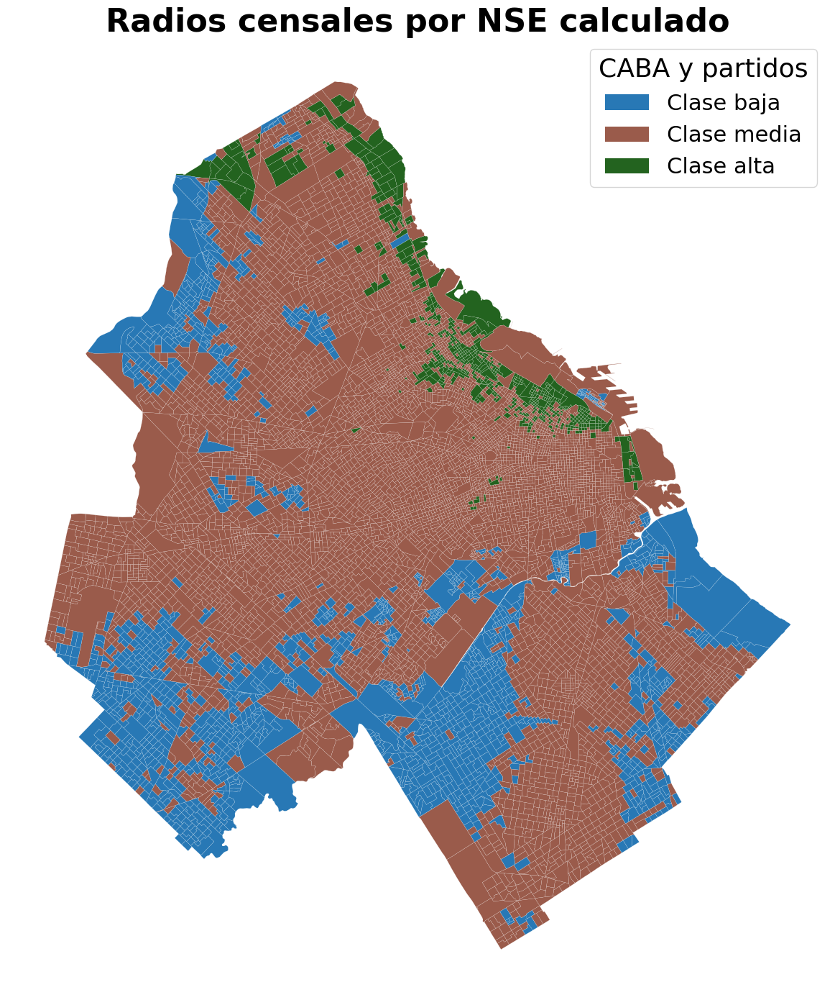

In [136]:
#El codigo de la celda anterior lo ejecuté en la compu de mi hermano ya que ahi puedo usar geopandas, lo guardé y me mandé la iamgen a la compu laboral
display(IPImage(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\RadiosCensalesNSE.png"))

In [19]:
clases = nx.get_node_attributes(G,"NSE")

#Primero elijo un nodo cualquiera y experimento
nodo_prueba = nodos["codigo"].iloc[0]
print("Nodo:", nodo_prueba)
print("Clase:", clases[nodo_prueba])

rng = np.random.default_rng(123)
tiempos, cantidad_clases_t, recorrido = UF.simular_caminata(
    G=G,
    clases=clases,
    nodo_inicial=nodo_prueba,
    max_pasos=5000,
    rng=rng,
    guardar_recorrido=True
)

print(tiempos,recorrido[:20])

resultado, valores_xk = UF.estimar_tiempos_nodo(
    G=G,
    clases=clases,
    nodo_inicial=nodo_prueba,
    numero_simulaciones=100,
    max_pasos=5000,
    semilla=123,
    nombre_configuracion="AMBA"
)

print(pd.DataFrame([resultado]).T)

resultado, valores_xk, resultado_caminatas = UF.estimar_tiempos_nodo_completo(
    G=G,
    clases=clases,
    nodo_inicial=nodo_prueba,
    numero_simulaciones=100,
    max_pasos=5000,
    semilla=123,
    nombre_configuracion="AMBA"
)

print(resultado_caminatas)

Nodo: 060350203
Clase: 2.0
{1: 0, 2: 2, 3: None} [('060350203', 2.0), ('060350205', 2.0), ('060350304', 3.0), ('060350306', 3.0), ('060350307', 3.0), ('060350205', 2.0), ('060350303', 3.0), ('060350312', 3.0), ('060350315', 3.0), ('060352202', 3.0), ('060352210', 3.0), ('060352202', 3.0), ('060350315', 3.0), ('060352203', 3.0), ('060350315', 3.0), ('060352203', 3.0), ('060352205', 3.0), ('060352203', 3.0), ('060350315', 3.0), ('060350312', 3.0)]
                                0
configuracion                AMBA
nodo                    060350203
clase_inicial                 2.0
simulaciones                  100
max_pasos                    5000
cantidad_total_clases           3
t2                           3.61
mediana_x2                    3.0
desvio_x2                2.420013
minimo_x2                     2.0
maximo_x2                    18.0
no_alcanzo_2                  0.0
t3                         3719.0
mediana_x3                 3783.0
desvio_x3              920.317492
minimo

In [19]:
nodo_alto = next(nodo for nodo, clase in clases.items() if clase == 4)
nodo_alto #Elijo uno de clase alta

resultado_alto, _ = UF.estimar_tiempos_nodo(
    G=G,
    clases=clases,
    nodo_inicial=nodo_alto,
    numero_simulaciones=100,
    max_pasos=5000,
    semilla=123,
    nombre_configuracion="AMBA"
)

print(pd.DataFrame([resultado_alto]).T)

resultado_alto, valores_xk_alto, resultado_caminatas_alto = UF.estimar_tiempos_nodo_completo(
    G=G,
    clases=clases,
    nodo_inicial=nodo_alto,
    numero_simulaciones=100,
    max_pasos=5000,
    semilla=123,
    nombre_configuracion="AMBA"
)

print(resultado_caminatas_alto)

                                0
configuracion                AMBA
nodo                    020841408
clase_inicial                 4.0
simulaciones                  100
max_pasos                    5000
cantidad_total_clases           3
t2                            1.0
mediana_x2                    1.0
desvio_x2                     0.0
minimo_x2                     1.0
maximo_x2                     1.0
no_alcanzo_2                  0.0
t3                          827.0
mediana_x3                  566.5
desvio_x3              826.708564
minimo_x3                    34.0
maximo_x3                  4320.0
no_alcanzo_3                  0.0
   configuracion       nodo  clase_inicial  simulacion  semilla_nodo  \
0           AMBA  020841408            4.0           0           123   
1           AMBA  020841408            4.0           1           123   
2           AMBA  020841408            4.0           2           123   
3           AMBA  020841408            4.0           3           1

In [27]:
rng_muestra = np.random.default_rng(123)
cantidad_radios_por_clase = 50 #Primero corro el experimento para 50 nodos por clase, a modo de muestra y para ver primeros resultados graficos
radios_muestra = {}

for clase in sorted(set(clases.values())):
    candidatos = np.array([nodo for nodo, valor_clase in clases.items() if valor_clase == clase])
    radios_muestra[clase] = rng_muestra.choice(candidatos,size=cantidad_radios_por_clase,replace=False)

for clase, radios_clase in radios_muestra.items():
    print(f"NSE {clase}: {len(radios_clase)} radios seleccionados") #Verifico estratificacion

NSE 2.0: 50 radios seleccionados
NSE 3.0: 50 radios seleccionados
NSE 4.0: 50 radios seleccionados


In [28]:
resultados_muestra = []
for clase, radios_clase in radios_muestra.items():
    for indice, radio in enumerate(radios_clase):
        semilla_nodo = (123 + int(clase) * 100_000 + indice)

        resultado, _, resultados_caminatas = UF.estimar_tiempos_nodo_completo(
            G=G,
            clases=clases,
            nodo_inicial=radio,
            numero_simulaciones=50,
            max_pasos=5000,
            semilla=semilla_nodo,
            nombre_configuracion="50nodos_maxt2000_numsim_200"
        )
        resultados_muestra.append(resultados_caminatas)

resultados_muestra_df = pd.concat(resultados_muestra,ignore_index=True)
print(resultados_muestra_df.shape)
resultados_muestra_df.head()

(7500, 10)


,configuracion,nodo,clase_inicial,simulacion,semilla_nodo,max_pasos,x2,alcanzo_2,x3,alcanzo_3
0,50nodos_maxt2000_numsim_200,064275409,2.0,0,200123,5000,1.0,True,1500.0,True
1,50nodos_maxt2000_numsim_200,064275409,2.0,1,200123,5000,18.0,True,1655.0,True
2,50nodos_maxt2000_numsim_200,064275409,2.0,2,200123,5000,1.0,True,NaN,False
3,50nodos_maxt2000_numsim_200,064275409,2.0,3,200123,5000,55.0,True,NaN,False
4,50nodos_maxt2000_numsim_200,064275409,2.0,4,200123,5000,6.0,True,2095.0,True


In [29]:
etiquetas_nse = {2: "NSE bajo",3: "NSE medio",4: "NSE alto"}
resultados_plot_muestra = resultados_muestra_df.copy()
resultados_plot_muestra["clase_nombre"] = (resultados_plot_muestra["clase_inicial"].astype(int).map(etiquetas_nse))

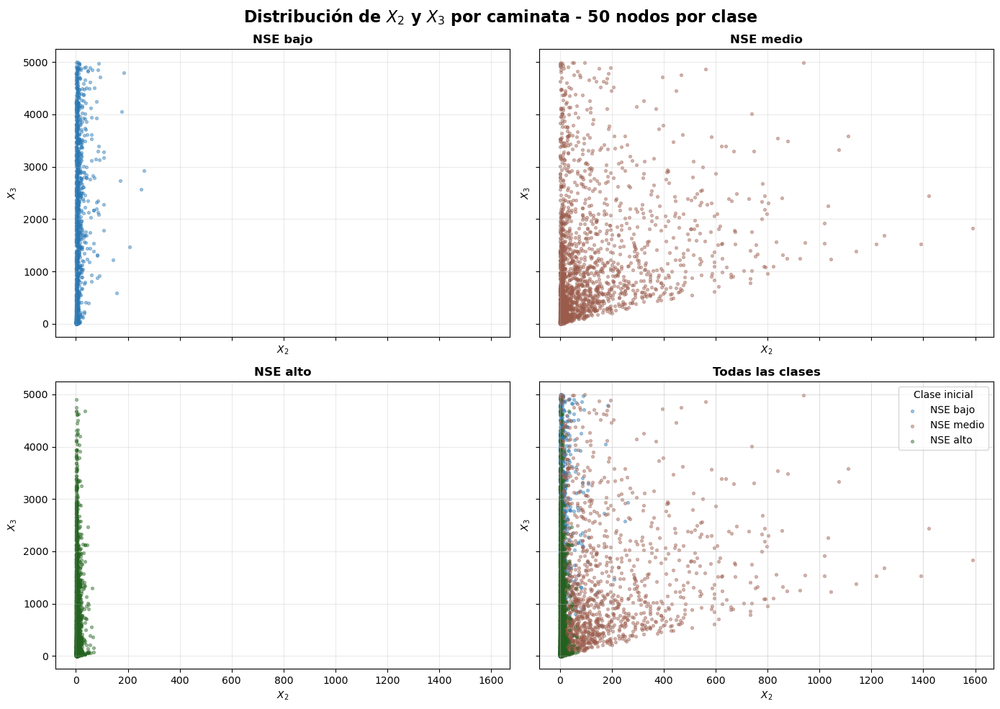

In [30]:
colores = {2: "#2878B5",3: "#9A5B4B",4: "#23631F"}
fig, axes = plt.subplots(2, 2,figsize=(14, 10),sharex=True,sharey=True)
clases_orden = [2, 3, 4]

for ax, clase in zip( [axes[0,0], axes[0,1], axes[1,0]],clases_orden):
    subset = resultados_plot_muestra.loc[resultados_plot_muestra["clase_inicial"] == clase]
    ax.scatter(
        subset["x2"],
        subset["x3"],
        alpha=0.4,
        s=8,
        color=colores[clase])
    ax.set_title(etiquetas_nse[clase],fontweight="bold")
    ax.set_xlabel(r"$X_2$")
    ax.set_ylabel(r"$X_3$")
    ax.grid(alpha=0.25)

# Panel inferior derecho: todos juntos
ax = axes[1,1]
for clase in clases_orden:
    subset = resultados_plot_muestra.loc[resultados_plot_muestra["clase_inicial"] == clase]
    ax.scatter(
        subset["x2"],
        subset["x3"],
        alpha=0.4,
        s=8,
        color=colores[clase],
        label=etiquetas_nse[clase]
    )

ax.set_title("Todas las clases",fontweight="bold")
ax.set_xlabel(r"$X_2$")
ax.set_ylabel(r"$X_3$")
ax.grid(alpha=0.4)
ax.legend(title="Clase inicial")
fig.suptitle("Distribución de $X_2$ y $X_3$ por caminata - 50 nodos por clase",fontsize=16,fontweight="bold")

plt.tight_layout()
plt.show()

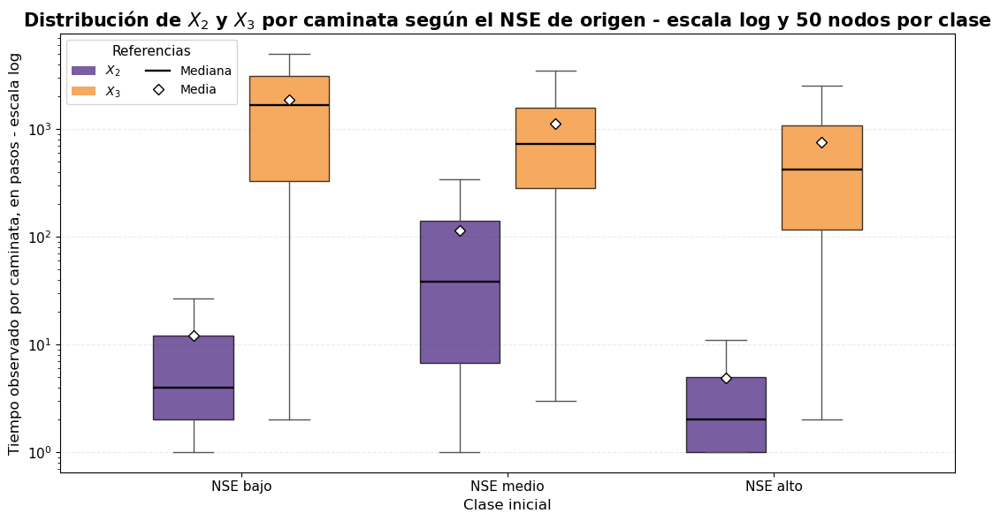

In [ ]:
colores_objetivo = {"x2": "#4c2882","x3": "#F28E2B"}
posiciones_clase = np.arange(len(clases_orden))
desplazamiento = 0.18 # Desplazamiento horizontal respecto del centro
ancho_caja = 0.30 # Ancho de cada caja

datos_x2_muestra = [resultados_plot_muestra.loc[resultados_plot_muestra["clase_inicial"] == clase,"x2"].dropna() for clase in clases_orden]
datos_x3_muestra = [resultados_plot_muestra.loc[resultados_plot_muestra["clase_inicial"] == clase,"x3"].dropna()for clase in clases_orden]
fig, ax = plt.subplots(figsize=(11, 6))

# X2 queda a la izquierda de cada clase
box_x2 = ax.boxplot(datos_x2_muestra, positions=(posiciones_clase - desplazamiento),
    widths=ancho_caja,patch_artist=True,showmeans=True,showfliers=False,
    medianprops={"color": "black","linewidth": 1.7},
    meanprops={"marker": "D","markerfacecolor": "white","markeredgecolor": "black","markersize": 6},
    whiskerprops={"color": "#555555","linewidth": 1},
    capprops={"color": "#555555","linewidth": 1}
)

# X3 queda a la derecha de cada clase
box_x3 = ax.boxplot(
    datos_x3_muestra,
    positions=( posiciones_clase + desplazamiento),
    widths=ancho_caja,patch_artist=True,showmeans=True,showfliers=False,
    medianprops={"color": "black","linewidth": 1.7},
    meanprops={"marker": "D","markerfacecolor": "white","markeredgecolor": "black","markersize": 6},
    whiskerprops={"color": "#555555","linewidth": 1},
    capprops={"color": "#555555","linewidth": 1})

for caja in box_x2["boxes"]:
    caja.set_facecolor(colores_objetivo["x2"])
    caja.set_alpha(0.75)

for caja in box_x3["boxes"]:
    caja.set_facecolor(colores_objetivo["x3"])
    caja.set_alpha(0.75)

ax.set_xticks(posiciones_clase)
ax.set_xticklabels([etiquetas_nse[clase] for clase in clases_orden],fontsize=11)
ax.set_xlabel("Clase inicial",fontsize=12)
ax.set_ylabel("Tiempo observado por caminata, en pasos - escala log",fontsize=12)
ax.set_title(r"Distribución de $X_2$ y $X_3$ por caminata según el NSE de origen - escala log y 50 nodos por clase",fontsize=15,fontweight="bold")
ax.tick_params(axis="y",labelsize=11)
ax.grid(axis="y",linestyle="--",alpha=0.25)

# Escala logarítmica para comparar X2 y X3
ax.set_yscale("log")

elementos_leyenda = [Patch(facecolor=colores_objetivo["x2"],alpha=0.75,label=r"$X_2$"),
                     Patch(facecolor=colores_objetivo["x3"],alpha=0.75,label=r"$X_3$"),
                     Line2D([0],[0],color="black",linewidth=1.7,label="Mediana"),
                     Line2D([0],[0],marker="D",markerfacecolor="white",markeredgecolor="black",linestyle="None",markersize=6,label="Media")]
ax.legend(handles=elementos_leyenda,title="Referencias",fontsize=10,title_fontsize=11,ncol=2)
plt.tight_layout()
plt.show()

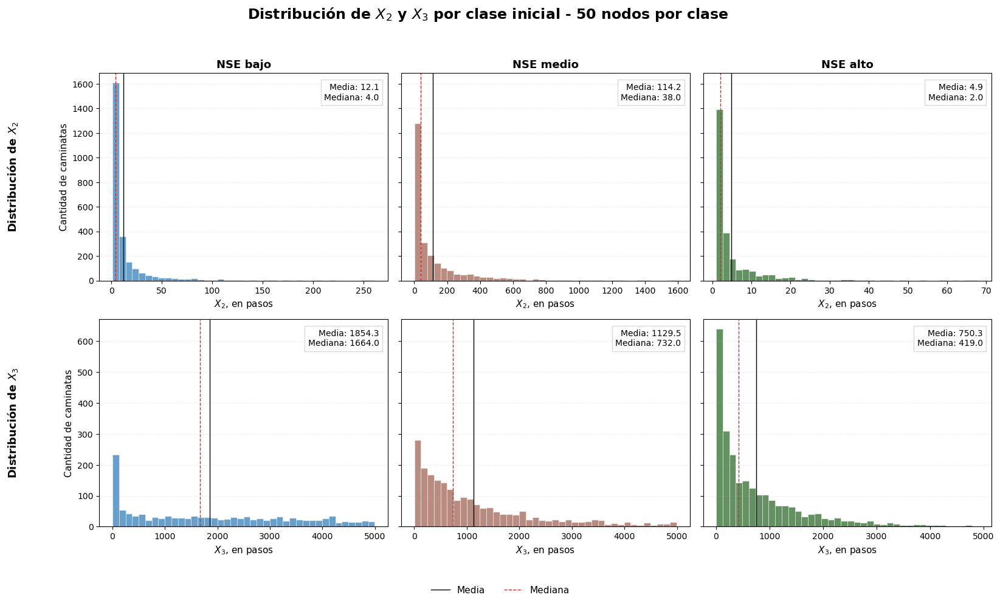

In [25]:
fig, axes = plt.subplots(nrows=2,ncols=3,figsize=(17, 10),sharex=False,sharey="row")
for columna, clase in enumerate(clases_orden):

    datos_clase_muestra= resultados_plot_muestra.loc[resultados_plot_muestra["clase_inicial"] == clase]
    valores_x2 = (datos_clase_muestra["x2"].dropna().to_numpy())
    media_x2 = np.mean(valores_x2)
    mediana_x2 = np.median(valores_x2)

    ax_x2 = axes[0, columna]
    ax_x2.hist(valores_x2,bins=40,color=colores[clase],alpha=0.70,edgecolor="white",linewidth=0.5)
    ax_x2.axvline(media_x2,color="black",linestyle="-",linewidth=1) #Media
    ax_x2.axvline(mediana_x2,color="#D62728",linestyle="--",linewidth=1) #Mediana
    ax_x2.set_title(etiquetas_nse[clase],fontsize=13,fontweight="bold")
    ax_x2.set_xlabel(r"$X_2$, en pasos",fontsize=11)
    ax_x2.grid(axis="y",linestyle="--",alpha=0.20)
    ax_x2.text(0.97,0.95,(f"Media: {media_x2:.1f}\n" f"Mediana: {mediana_x2:.1f}"),
        transform=ax_x2.transAxes,ha="right",va="top",fontsize=10,
        bbox={"facecolor": "white","edgecolor": "lightgray","alpha": 0.85})
    
    if columna == 0:
        ax_x2.set_ylabel("Cantidad de caminatas",fontsize=11)

    valores_x3 = (datos_clase_muestra["x3"].dropna().to_numpy())
    media_x3 = np.mean(valores_x3)
    mediana_x3 = np.median(valores_x3)

    ax_x3 = axes[1, columna]
    ax_x3.hist(valores_x3,bins=40,color=colores[clase],alpha=0.70,edgecolor="white",linewidth=0.5)
    ax_x3.axvline(media_x3,color="black",linestyle="-",linewidth=1)
    ax_x3.axvline(mediana_x3,color="#D62728",linestyle="--",linewidth=1)
    ax_x3.set_xlabel(r"$X_3$, en pasos",fontsize=11)
    ax_x3.grid(axis="y",linestyle="--",alpha=0.20)
    ax_x3.text(0.97,0.95,(f"Media: {media_x3:.1f}\n" f"Mediana: {mediana_x3:.1f}"),
        transform=ax_x3.transAxes,ha="right",va="top",fontsize=10,
        bbox={"facecolor": "white","edgecolor": "lightgray","alpha": 0.85})
    
    if columna == 0:
        ax_x3.set_ylabel("Cantidad de caminatas",fontsize=11)

axes[0, 0].annotate(r"Distribución de $X_2$", xy=(-0.30, 0.5),xycoords="axes fraction",rotation=90,ha="center",va="center",fontsize=13,fontweight="bold")
axes[1, 0].annotate(r"Distribución de $X_3$", xy=(-0.30, 0.5),xycoords="axes fraction",rotation=90,ha="center",va="center",fontsize=13,fontweight="bold")

elementos_leyenda = [Line2D([0],[0],color="black",linestyle="-",linewidth=1,label="Media"),
                     Line2D([0],[0],color="#D62728",linestyle="--",linewidth=1,label="Mediana")]

fig.legend(handles=elementos_leyenda,loc="lower center",ncol=2,fontsize=11,frameon=False)
fig.suptitle(r"Distribución de $X_2$ y $X_3$ por clase inicial - 50 nodos por clase",fontsize=17,fontweight="bold")

plt.tight_layout(rect=[0.04, 0.06, 1, 0.95])
plt.show() #Todas distribuciones asimetricas

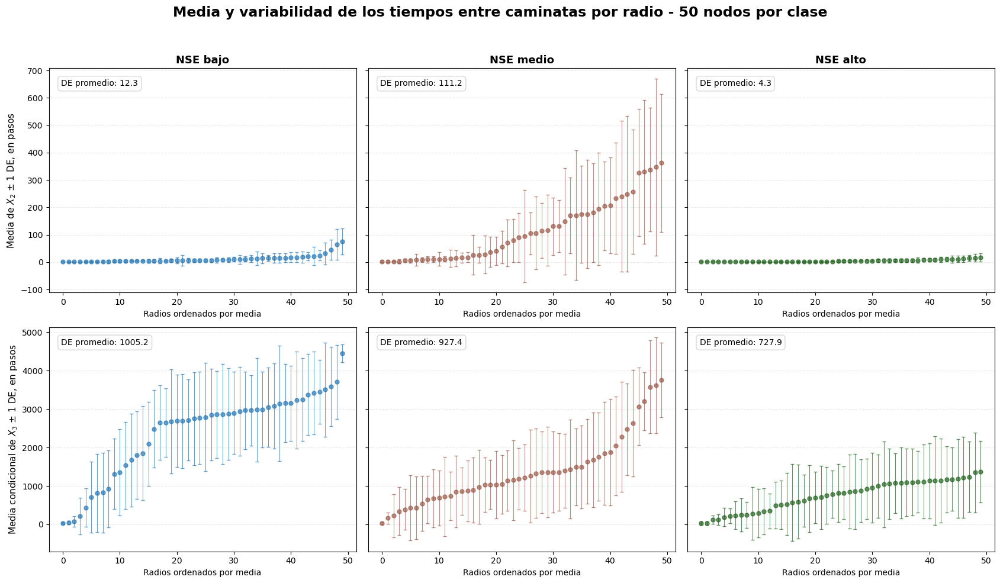

In [258]:
resumen_por_radio_muestra = (resultados_plot_muestra.groupby(["nodo","clase_inicial"],as_index=False)
    .agg(
        media_x2=("x2", "mean"),
        desvio_x2=("x2", "std"),
        mediana_x2=("x2", "median"),
        cantidad_x2=("x2", "count"),
        media_x3=("x3", "mean"),
        desvio_x3=("x3", "std"),
        mediana_x3=("x3", "median"),
        cantidad_x3=("x3", "count"),
        total_caminatas=("simulacion", "size")
    )
)

resumen_por_radio_muestra["no_alcanzo_3"] = ( 1 - resumen_por_radio_muestra["cantidad_x3"] / resumen_por_radio_muestra["total_caminatas"])

fig, axes = plt.subplots(nrows=2,ncols=3,figsize=(17, 10),sharey="row")

for columna, clase in enumerate(clases_orden):
    datos_clase = resumen_por_radio_muestra.loc[resumen_por_radio_muestra["clase_inicial"] == clase].copy()
    desvio_promedio_x2 = datos_clase["desvio_x2"].mean()
    desvio_promedio_x3 = datos_clase["desvio_x3"].mean()

    datos_x2 = (datos_clase.sort_values("media_x2").reset_index(drop=True))
    posiciones_x2 = np.arange(len(datos_x2))
    axes[0, columna].errorbar(posiciones_x2,datos_x2["media_x2"],yerr=datos_x2["desvio_x2"].fillna(0),fmt="o",markersize=5,
                              linewidth=0.8,elinewidth=0.8,capsize=2,color=colores[clase],ecolor=colores[clase],alpha=0.70)
    axes[0, columna].text(0.04,0.95,f"DE promedio: {desvio_promedio_x2:.1f}",transform=axes[0, columna].transAxes,ha="left",va="top",
                          fontsize=10,bbox={"facecolor": "white","edgecolor": "lightgray","alpha": 0.90,"boxstyle": "round,pad=0.4"})
    axes[0, columna].set_title(etiquetas_nse[clase],fontsize=13,fontweight="bold")
    axes[0, columna].set_xlabel("Radios ordenados por media")
    axes[0, columna].grid(axis="y",linestyle="--",alpha=0.25)

    datos_x3 = (datos_clase.sort_values("media_x3").reset_index(drop=True))

    posiciones_x3 = np.arange(len(datos_x3))
    axes[1, columna].errorbar(posiciones_x3,datos_x3["media_x3"],yerr=datos_x3["desvio_x3"].fillna(0),fmt="o",markersize=5,linewidth=0.8,
                              elinewidth=0.8,capsize=2,color=colores[clase],ecolor=colores[clase],alpha=0.70)
    axes[1, columna].text(0.04,0.95,f"DE promedio: {desvio_promedio_x3:.1f}",transform=axes[1, columna].transAxes,ha="left",va="top",
                          fontsize=10,bbox={"facecolor": "white","edgecolor": "lightgray","alpha": 0.90,"boxstyle": "round,pad=0.4"})
    axes[1, columna].set_xlabel("Radios ordenados por media")
    axes[1, columna].grid(axis="y",linestyle="--",alpha=0.25)

axes[0, 0].set_ylabel(r"Media de $X_2$ ± 1 DE, en pasos",fontsize=11)
axes[1, 0].set_ylabel(r"Media condicional de $X_3$ ± 1 DE, en pasos",fontsize=11)

fig.suptitle("Media y variabilidad de los tiempos entre caminatas por radio - 50 nodos por clase",fontsize=17,fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [262]:
#Hago sweep en max_pasos y numero de simulaciones
horizontes = [1000,2500,5000,8000]
numeros_simulaciones = [25,50,100,200]
maximo_horizonte = max(horizontes)
maximas_simulaciones = max(numeros_simulaciones)
resultados_sweep = []

for clase, radios_clase in radios_muestra.items():
    print(f"Procesando clase {clase}: "f"{len(radios_clase)} radios")

    for indice, radio in enumerate(radios_clase):
        semilla_nodo = ( 123 + int(clase) * 100_000 + indice)
        resultado_maximo, valores_xk = (
            UF.estimar_tiempos_nodo(
                G=G,
                clases=clases,
                nodo_inicial=radio,
                numero_simulaciones=maximas_simulaciones,
                max_pasos=maximo_horizonte,
                semilla=semilla_nodo,
                nombre_configuracion="AMBA_CABA_sweep"
            )
        )

        tiempos_x2_completos = valores_xk[2]
        tiempos_x3_completos = valores_xk[3]

        for numero_simulaciones in numeros_simulaciones:

            # Tomamos las primeras N caminatas
            tiempos_x2 = tiempos_x2_completos[:numero_simulaciones]
            tiempos_x3 = tiempos_x3_completos[:numero_simulaciones]

            # Sweep de horizonte máximo

            for horizonte in horizontes:

                alcanzo_2 = (~np.isnan(tiempos_x2) & (tiempos_x2 <= horizonte))
                alcanzo_3 = (~np.isnan(tiempos_x3) & (tiempos_x3 <= horizonte))
                tiempos_x2_h = tiempos_x2[alcanzo_2]
                tiempos_x3_h = tiempos_x3[alcanzo_3]
                resultados_sweep.append(
                        {"nodo": radio,
                        "clase_inicial": int(clase),
                        "numero_simulaciones": (numero_simulaciones),
                        "horizonte": horizonte,
                        "cantidad_alcanzo_2": (alcanzo_2.sum()),
                        "cantidad_alcanzo_3": (alcanzo_3.sum()),
                        "proporcion_alcanzo_2": (alcanzo_2.mean()),
                        "proporcion_alcanzo_3": (alcanzo_3.mean()),
                        "no_alcanzo_2": (1 - alcanzo_2.mean()),
                        "no_alcanzo_3": (1 - alcanzo_3.mean()),
                        "t2": (tiempos_x2_h.mean() if len(tiempos_x2_h) > 0 else np.nan),
                        "t3": (tiempos_x3_h.mean() if len(tiempos_x3_h) > 0 else np.nan),
                        "mediana_t2": (np.median(tiempos_x2_h) if len(tiempos_x2_h) > 0 else np.nan),
                        "mediana_t3": (np.median(tiempos_x3_h) if len(tiempos_x3_h) > 0 else np.nan),
                        "desvio_t2": (np.std(tiempos_x2_h,ddof=1) if len(tiempos_x2_h) > 1 else np.nan),
                        "desvio_t3": ( np.std(tiempos_x3_h,ddof=1) if len(tiempos_x3_h) > 1 else np.nan)})

Procesando clase 2.0: 50 radios
Procesando clase 3.0: 50 radios
Procesando clase 4.0: 50 radios


In [288]:
pd.DataFrame(resultados_sweep).head(20)

,nodo,clase_inicial,numero_simulaciones,horizonte,cantidad_alcanzo_2,cantidad_alcanzo_3,proporcion_alcanzo_2,proporcion_alcanzo_3,no_alcanzo_2,no_alcanzo_3,t2,t3,mediana_t2,mediana_t3,desvio_t2,desvio_t3
0,064275409,2,25,1000,25,1,1.0,0.040,0.0,0.960,9.24,725.000000,2.0,725.0,11.281548,NaN
1,064275409,2,25,2500,25,5,1.0,0.200,0.0,0.800,9.24,1573.200000,2.0,1654.0,11.281548,573.105313
2,064275409,2,25,5000,25,12,1.0,0.480,0.0,0.520,9.24,2794.500000,2.0,2581.5,11.281548,1355.747060
3,064275409,2,25,8000,25,19,1.0,0.760,0.0,0.240,9.24,4072.526316,2.0,3980.0,11.281548,2101.677276
4,064275409,2,50,1000,50,1,1.0,0.020,0.0,0.980,7.72,725.000000,2.0,725.0,10.598498,NaN
5,064275409,2,50,2500,50,10,1.0,0.200,0.0,0.800,7.72,1641.000000,2.0,1654.5,10.598498,517.840602
6,064275409,2,50,5000,50,25,1.0,0.500,0.0,0.500,7.72,2831.000000,2.0,2565.0,10.598498,1236.469571
7,064275409,2,50,8000,50,33,1.0,0.660,0.0,0.340,7.72,3655.303030,2.0,3487.0,10.598498,1878.406747
8,064275409,2,100,1000,100,2,1.0,0.020,0.0,0.980,6.58,664.000000,2.0,664.0,9.426140,86.267027
9,064275409,2,100,2500,100,22,1.0,0.220,0.0,0.780,6.58,1795.818182,2.0,1767.0,9.426140,537.315783


,clase_inicial,numero_simulaciones,horizonte,no_alcanzo_3_promedio,no_alcanzo_3_mediana,t2_promedio,t2_mediana,t3_promedio,t3_mediana,cantidad_radios
0,2,25,1000,0.8192,1.00,11.9584,6.80,472.469357,538.400000,50
1,2,25,2500,0.6632,0.80,11.9584,6.80,1421.003862,1577.200000,50
2,2,25,5000,0.4808,0.54,11.9584,6.80,2369.401953,2774.645455,50
3,2,25,8000,0.3552,0.36,11.9584,6.80,3253.084342,3698.131944,50
4,2,50,1000,0.8112,0.98,12.3196,6.73,526.817106,570.888889,50


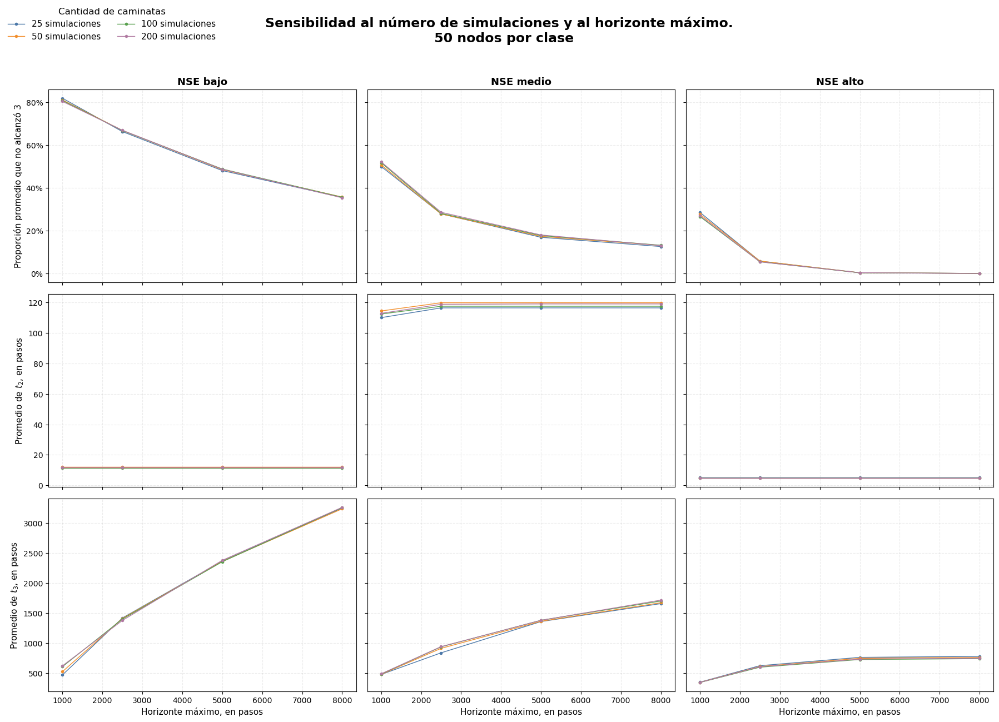

In [285]:
resultados_sweep_df = pd.DataFrame(resultados_sweep)
resumen_sweep = (resultados_sweep_df.groupby(["clase_inicial","numero_simulaciones","horizonte"],as_index=False)
                 .agg( 
                 no_alcanzo_3_promedio=("no_alcanzo_3","mean"), 
                 no_alcanzo_3_mediana=("no_alcanzo_3","median"),
                 t2_promedio=("t2","mean"),
                 t2_mediana=("t2","median"),
                 t3_promedio=("t3","mean"),
                 t3_mediana=("t3","median"),
                 cantidad_radios=("nodo","nunique")))

display(resumen_sweep.head())
colores_simulaciones = {25: "#4C78A8",50: "#F28E2B",100: "#59A14F",200: "#B07AA1"}
fig, axes = plt.subplots(nrows=3,ncols=3,figsize=(18, 14),sharex=True,sharey="row")

for columna, clase in enumerate(clases_orden):

    datos_clase = resumen_sweep.loc[resumen_sweep["clase_inicial"] == clase]
    for numero_simulaciones in numeros_simulaciones:

        datos_linea = (datos_clase.loc[datos_clase["numero_simulaciones"] == numero_simulaciones].sort_values("horizonte"))
        color = colores_simulaciones[numero_simulaciones]

        axes[0, columna].plot(datos_linea["horizonte"],datos_linea["no_alcanzo_3_promedio"],marker=".",linewidth=1,color=color,label=(f"{numero_simulaciones} ""simulaciones"))
        axes[1, columna].plot(datos_linea["horizonte"],datos_linea["t2_promedio"],marker=".",linewidth=1,color=color)
        axes[2, columna].plot(datos_linea["horizonte"],datos_linea["t3_promedio"],marker=".",linewidth=1,color=color)

    axes[0, columna].set_title(etiquetas_nse[clase],fontsize=13,fontweight="bold")
    axes[2, columna].set_xlabel("Horizonte máximo, en pasos",fontsize=11)

    for fila in range(3):
        axes[fila, columna].grid(linestyle="--",alpha=0.25)

# Etiquetas verticales
axes[0, 0].set_ylabel(r"Proporción promedio que no alcanzó 3",fontsize=11)
axes[1, 0].set_ylabel(r"Promedio de $t_2$, en pasos",fontsize=11)
axes[2, 0].set_ylabel(r"Promedio de $t_3$, en pasos",fontsize=11)

# Mostrar no_alcanzo_3 como porcentaje
for ax in axes[0, :]:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1,decimals=0))

handles, labels = (axes[0, 0].get_legend_handles_labels())
fig.legend(handles,labels,title="Cantidad de caminatas",loc="upper left",ncol=2,fontsize=11,title_fontsize=12,frameon=False)
fig.suptitle("Sensibilidad al número de simulaciones y al horizonte máximo. \n 50 nodos por clase",fontsize=17,fontweight="bold")
plt.tight_layout(rect=[0, 0.07, 1, 0.96])
plt.show()

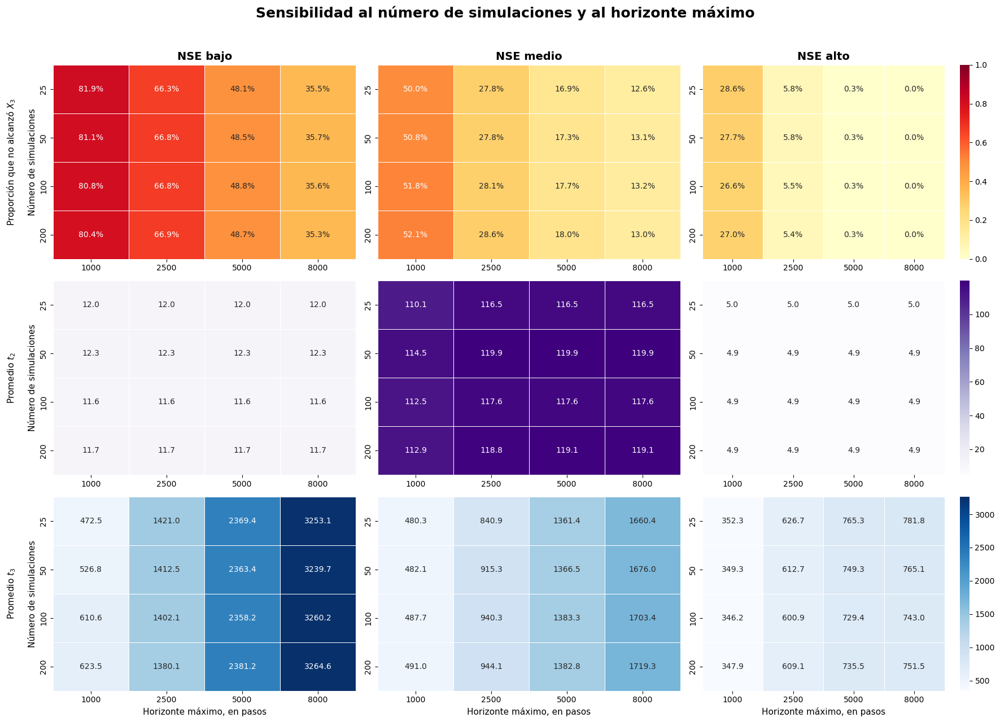

In [290]:
metricas_heatmap = [
    {"columna": "no_alcanzo_3_promedio","titulo": r"Proporción que no alcanzó $X_3$","cmap": "YlOrRd","formato": ".1%","vmin": 0,"vmax": 1},
    {"columna": "t2_promedio","titulo": r"Promedio $t_2$","cmap": "Purples","formato": ".1f",
     "vmin": resumen_sweep["t2_promedio"].min(),"vmax": resumen_sweep["t2_promedio"].max()},
    {"columna": "t3_promedio","titulo": r"Promedio $t_3$","cmap": "Blues","formato": ".1f",
     "vmin": resumen_sweep["t3_promedio"].min(),"vmax": resumen_sweep["t3_promedio"].max()}]

fig, axes = plt.subplots(nrows=3,ncols=3,figsize=(18, 13))

for fila, configuracion_metrica in enumerate(metricas_heatmap):
    metrica = configuracion_metrica["columna"]
    for columna, clase in enumerate(clases_orden):
        datos_clase = resumen_sweep.loc[resumen_sweep["clase_inicial"] == clase]
        matriz = datos_clase.pivot(index="numero_simulaciones",columns="horizonte",values=metrica)
        matriz = matriz.reindex(index=numeros_simulaciones,columns=horizontes)
        sns.heatmap(matriz,ax=axes[fila, columna],annot=True,
            fmt=configuracion_metrica["formato"],cmap=configuracion_metrica["cmap"],
            vmin=configuracion_metrica["vmin"],vmax=configuracion_metrica["vmax"],
            linewidths=0.5,linecolor="white",
            cbar=(columna == 2),annot_kws={"fontsize": 10})
        
        if fila == 0:
            axes[fila, columna].set_title(etiquetas_nse[clase],fontsize=14,fontweight="bold")
        if columna == 0:
            axes[fila, columna].set_ylabel((configuracion_metrica["titulo"] + "\n\nNúmero de simulaciones"),fontsize=11)
        else:
            axes[fila, columna].set_ylabel("")

        if fila == 2:
            axes[fila, columna].set_xlabel("Horizonte máximo, en pasos",fontsize=11)
        else:
            axes[fila, columna].set_xlabel("")

fig.suptitle("Sensibilidad al número de simulaciones y al horizonte máximo",fontsize=18,fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [20]:
#Corrida para TODOS los radios censales
TODOS_LOS_RADIOS = list(G.nodes())
resultados_completos = []

for i, radio in enumerate(TODOS_LOS_RADIOS):
    if i % 100 == 0:
        print(f"{i}/{len(TODOS_LOS_RADIOS)}")

    resultado, _ = UF.estimar_tiempos_nodo(
        G=G,
        clases=clases,
        nodo_inicial=radio,
        numero_simulaciones=50, #Achico el numero de caminatas por nodo porque sino se hace demasiado largo
        max_pasos=5000,
        semilla=123 + i,
        nombre_configuracion="amba_caba_todos_los_radios_5000_pasos_50_sim"
    )

    resultados_completos.append(resultado)

resultados_completos_df = pd.DataFrame(resultados_completos)

0/8847


c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


100/8847
200/8847
300/8847
400/8847
500/8847
600/8847
700/8847
800/8847
900/8847
1000/8847
1100/8847
1200/8847
1300/8847
1400/8847
1500/8847
1600/8847
1700/8847
1800/8847
1900/8847
2000/8847
2100/8847
2200/8847
2300/8847
2400/8847
2500/8847
2600/8847
2700/8847
2800/8847
2900/8847
3000/8847
3100/8847
3200/8847
3300/8847
3400/8847
3500/8847
3600/8847
3700/8847
3800/8847
3900/8847
4000/8847
4100/8847
4200/8847
4300/8847
4400/8847
4500/8847
4600/8847
4700/8847
4800/8847
4900/8847
5000/8847
5100/8847
5200/8847
5300/8847
5400/8847
5500/8847
5600/8847
5700/8847
5800/8847
5900/8847
6000/8847
6100/8847
6200/8847
6300/8847
6400/8847
6500/8847
6600/8847
6700/8847
6800/8847
6900/8847
7000/8847
7100/8847
7200/8847
7300/8847
7400/8847
7500/8847
7600/8847
7700/8847
7800/8847
7900/8847
8000/8847
8100/8847
8200/8847
8300/8847
8400/8847
8500/8847
8600/8847
8700/8847
8800/8847


In [21]:
print(resultados_completos_df.head())

                                  configuracion       nodo  clase_inicial  \
0  amba_caba_todos_los_radios_5000_pasos_50_sim  060350203            2.0   
1  amba_caba_todos_los_radios_5000_pasos_50_sim  060350205            2.0   
2  amba_caba_todos_los_radios_5000_pasos_50_sim  060350302            2.0   
3  amba_caba_todos_los_radios_5000_pasos_50_sim  060350204            2.0   
4  amba_caba_todos_los_radios_5000_pasos_50_sim  060350202            2.0   

   simulaciones  max_pasos  cantidad_total_clases    t2  mediana_x2  \
0            50       5000                      3  3.46         3.0   
1            50       5000                      3  2.54         1.0   
2            50       5000                      3  2.74         2.5   
3            50       5000                      3  3.26         2.0   
4            50       5000                      3  3.18         2.0   

   desvio_x2  minimo_x2  maximo_x2  no_alcanzo_2           t3  mediana_x3  \
0   1.864929        2.0        9.

In [22]:
datos_largos = pd.concat([resultados_completos_df[["nodo","clase_inicial","t2"]].rename(columns={"t2": "tiempo"}).assign(objetivo="t2",x=2),
                          resultados_completos_df[["nodo","clase_inicial","t3"]].rename(columns={"t3": "tiempo"}).assign(objetivo="t3",x=3)],
                          ignore_index=True)   
print(datos_largos.head())                

        nodo  clase_inicial  tiempo objetivo  x
0  060350203            2.0    3.46       t2  2
1  060350205            2.0    2.54       t2  2
2  060350302            2.0    2.74       t2  2
3  060350204            2.0    3.26       t2  2
4  060350202            2.0    3.18       t2  2


In [25]:
resumen = (resultados_completos_df.groupby("clase_inicial")[["t2","t3","no_alcanzo_3"]].agg(["mean","median","std"]))
resumen

t2                             t3               \
                    mean median        std         mean       median   
clase_inicial                                                          
2.0            14.589988   8.10  16.378484  2299.780156  2593.040373   
3.0            97.640738  65.43  95.521753  1627.988452  1312.104932   
4.0             5.031972   3.16   4.336867   752.673899   851.440000   

                          no_alcanzo_3                   
                      std         mean median       std  
clase_inicial                                            
2.0            956.435455     0.480674   0.52  0.263150  
3.0            957.109174     0.259878   0.12  0.289913  
4.0            343.656551     0.003106   0.00  0.008072

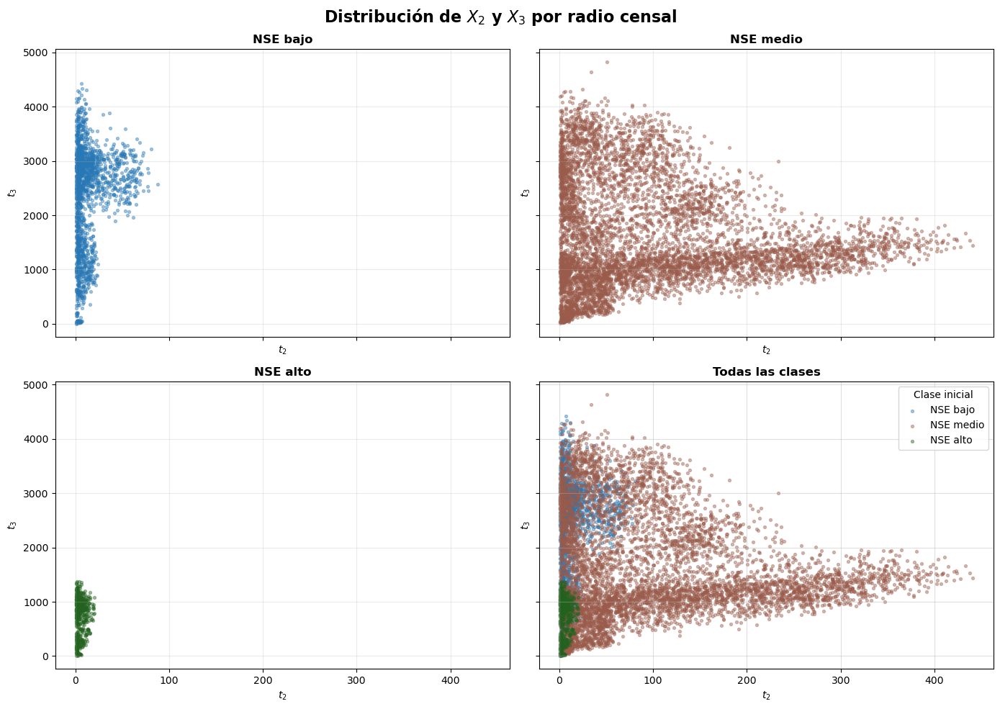

In [31]:
#Recreo los graficos anteriores  
resultados_plot_completos= resultados_completos_df.copy()
resultados_plot_completos["clase_nombre"] = (resultados_plot_completos["clase_inicial"].astype(int).map(etiquetas_nse))

fig, axes = plt.subplots(2, 2,figsize=(14, 10),sharex=True,sharey=True)
for ax, clase in zip( [axes[0,0], axes[0,1], axes[1,0]],clases_orden):
    subset = resultados_plot_completos.loc[resultados_plot_completos["clase_inicial"] == clase]
    ax.scatter(
        subset["t2"],
        subset["t3"],
        alpha=0.4,
        s=8,
        color=colores[clase])
    ax.set_title(etiquetas_nse[clase],fontweight="bold")
    ax.set_xlabel(r"$t_2$")
    ax.set_ylabel(r"$t_3$")
    ax.grid(alpha=0.25)

# Panel inferior derecho: todos juntos
ax = axes[1,1]
for clase in clases_orden:
    subset = resultados_plot_completos.loc[resultados_plot_completos["clase_inicial"] == clase]
    ax.scatter(
        subset["t2"],
        subset["t3"],
        alpha=0.4,
        s=8,
        color=colores[clase],
        label=etiquetas_nse[clase]
    )

ax.set_title("Todas las clases",fontweight="bold")
ax.set_xlabel(r"$t_2$")
ax.set_ylabel(r"$t_3$")
ax.grid(alpha=0.4)
ax.legend(title="Clase inicial")
fig.suptitle("Distribución de $X_2$ y $X_3$ por radio censal",fontsize=16,fontweight="bold")

plt.tight_layout()
plt.show()

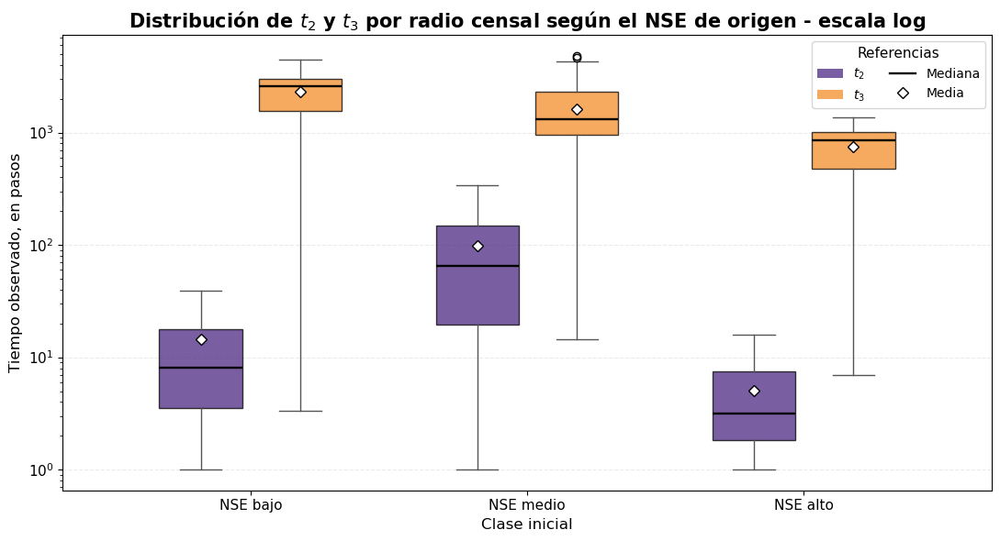

In [303]:
colores_objetivo_comp = {"t2": "#4c2882","t3": "#F28E2B"}
datos_t2_completo = [resultados_plot_completos.loc[resultados_plot_completos["clase_inicial"] == clase,"t2"].dropna() for clase in clases_orden]
datos_t3_completo = [resultados_plot_completos.loc[resultados_plot_completos["clase_inicial"] == clase,"t3"].dropna() for clase in clases_orden]
fig, ax = plt.subplots(figsize=(11, 6))

# t2 queda a la izquierda de cada clase
box_t2 = ax.boxplot(datos_t2_completo, positions=(posiciones_clase - desplazamiento),
    widths=ancho_caja,patch_artist=True,showmeans=True,showfliers=False,
    medianprops={"color": "black","linewidth": 1.7},
    meanprops={"marker": "D","markerfacecolor": "white","markeredgecolor": "black","markersize": 6},
    whiskerprops={"color": "#555555","linewidth": 1},
    capprops={"color": "#555555","linewidth": 1}
)

# t3 queda a la derecha de cada clase
box_t3 = ax.boxplot(
    datos_t3_completo,
    positions=( posiciones_clase + desplazamiento),
    widths=ancho_caja,patch_artist=True,showmeans=True,showfliers=True,
    medianprops={"color": "black","linewidth": 1.7},
    meanprops={"marker": "D","markerfacecolor": "white","markeredgecolor": "black","markersize": 6},
    whiskerprops={"color": "#555555","linewidth": 1},
    capprops={"color": "#555555","linewidth": 1})

for caja in box_t2["boxes"]:
    caja.set_facecolor(colores_objetivo_comp["t2"])
    caja.set_alpha(0.75)

for caja in box_t3["boxes"]:
    caja.set_facecolor(colores_objetivo_comp["t3"])
    caja.set_alpha(0.75)

ax.set_xticks(posiciones_clase)
ax.set_xticklabels([etiquetas_nse[clase] for clase in clases_orden],fontsize=11)
ax.set_xlabel("Clase inicial",fontsize=12)
ax.set_ylabel("Tiempo observado, en pasos",fontsize=12)
ax.set_title(r"Distribución de $t_2$ y $t_3$ por radio censal según el NSE de origen - escala log",fontsize=15,fontweight="bold")
ax.tick_params(axis="y",labelsize=11)
ax.grid(axis="y",linestyle="--",alpha=0.25)

# Escala logarítmica para comparar t2 y t3
ax.set_yscale("log")

elementos_leyenda = [Patch(facecolor=colores_objetivo_comp["t2"],alpha=0.75,label=r"$t_2$"),
                     Patch(facecolor=colores_objetivo_comp["t3"],alpha=0.75,label=r"$t_3$"),
                     Line2D([0],[0],color="black",linewidth=1.7,label="Mediana"),
                     Line2D([0],[0],marker="D",markerfacecolor="white",markeredgecolor="black",linestyle="None",markersize=6,label="Media")]
ax.legend(handles=elementos_leyenda,title="Referencias",fontsize=10,title_fontsize=11,ncol=2)
plt.tight_layout()
plt.show()

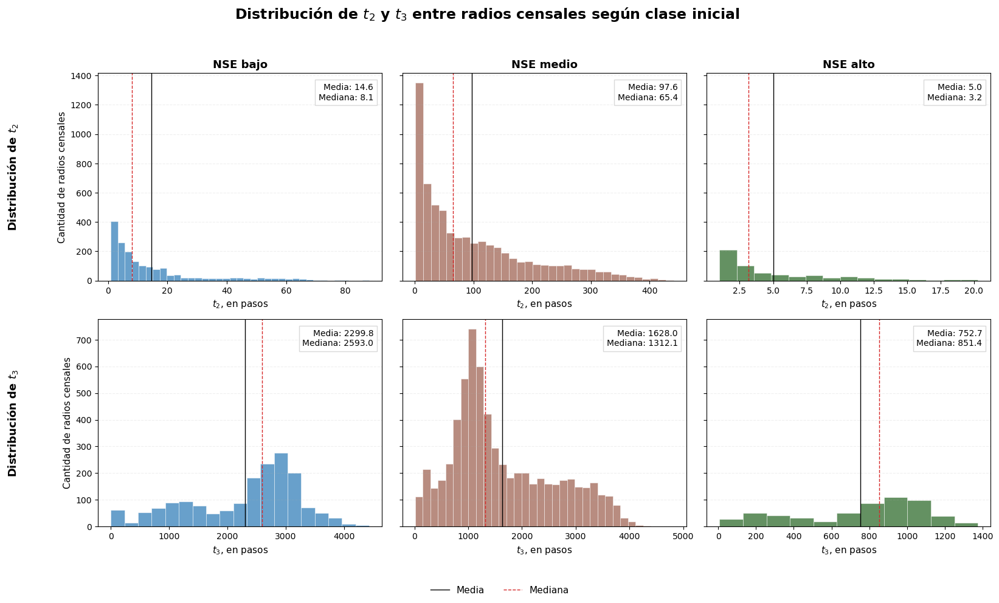

In [310]:
fig, axes = plt.subplots(nrows=2,ncols=3,figsize=(17, 10),sharex=False,sharey="row")
for columna, clase in enumerate(clases_orden):

    datos_clase_comp= resultados_plot_completos.loc[resultados_plot_completos["clase_inicial"] == clase]
    valores_t2 = (datos_clase_comp["t2"].dropna().to_numpy())
    media_t2 = np.mean(valores_t2)
    mediana_t2 = np.median(valores_t2)

    ax_x2 = axes[0, columna]
    ax_x2.hist(valores_t2,bins="auto",color=colores[clase],alpha=0.70,edgecolor="white",linewidth=0.5)
    ax_x2.axvline(media_t2,color="black",linestyle="-",linewidth=1) #Media
    ax_x2.axvline(mediana_t2,color="#D62728",linestyle="--",linewidth=1) #Mediana
    ax_x2.set_title(etiquetas_nse[clase],fontsize=13,fontweight="bold")
    ax_x2.set_xlabel(r"$t_2$, en pasos",fontsize=11)
    ax_x2.grid(axis="y",linestyle="--",alpha=0.20)
    ax_x2.text(0.97,0.95,(f"Media: {media_t2:.1f}\n" f"Mediana: {mediana_t2:.1f}"),
        transform=ax_x2.transAxes,ha="right",va="top",fontsize=10,
        bbox={"facecolor": "white","edgecolor": "lightgray","alpha": 0.85})
    
    if columna == 0:
        ax_x2.set_ylabel("Cantidad de radios censales",fontsize=11)

    valores_t3 = (datos_clase_comp["t3"].dropna().to_numpy())
    media_t3 = np.mean(valores_t3)
    mediana_t3 = np.median(valores_t3)

    ax_x3 = axes[1, columna]
    ax_x3.hist(valores_t3,bins="auto",color=colores[clase],alpha=0.70,edgecolor="white",linewidth=0.5)
    ax_x3.axvline(media_t3,color="black",linestyle="-",linewidth=1)
    ax_x3.axvline(mediana_t3,color="#D62728",linestyle="--",linewidth=1)
    ax_x3.set_xlabel(r"$t_3$, en pasos",fontsize=11)
    ax_x3.grid(axis="y",linestyle="--",alpha=0.20)
    ax_x3.text(0.97,0.95,(f"Media: {media_t3:.1f}\n" f"Mediana: {mediana_t3:.1f}"),
        transform=ax_x3.transAxes,ha="right",va="top",fontsize=10,
        bbox={"facecolor": "white","edgecolor": "lightgray","alpha": 0.85})
    
    if columna == 0:
        ax_x3.set_ylabel("Cantidad de radios censales",fontsize=11)

axes[0, 0].annotate(r"Distribución de $t_2$", xy=(-0.30, 0.5),xycoords="axes fraction",rotation=90,ha="center",va="center",fontsize=13,fontweight="bold")
axes[1, 0].annotate(r"Distribución de $t_3$", xy=(-0.30, 0.5),xycoords="axes fraction",rotation=90,ha="center",va="center",fontsize=13,fontweight="bold")

elementos_leyenda = [Line2D([0],[0],color="black",linestyle="-",linewidth=1,label="Media"),
                     Line2D([0],[0],color="#D62728",linestyle="--",linewidth=1,label="Mediana")]

fig.legend(handles=elementos_leyenda,loc="lower center",ncol=2,fontsize=11,frameon=False)
fig.suptitle(r"Distribución de $t_2$ y $t_3$ entre radios censales según clase inicial",fontsize=17,fontweight="bold")

plt.tight_layout(rect=[0.04, 0.06, 1, 0.95])
plt.show()

In [71]:
print(resultados_completos_df["no_alcanzo_2"].value_counts()) #Esperaria ver todo 0
resultados_completos_df["no_alcanzo_3"].describe() # max = 0.98 < 1, es decir no pasó para ningun nodo que ninguna de las 50 simulaciones haya encontrado las 3 clases, 
                                                   # al menos una simulacion tuvo un recorrido que encontró las 3 clases, para cada nodo.

no_alcanzo_2
0.0    8847
Name: count, dtype: int64


count    8847.000000
mean        0.286174
std         0.297963
min         0.000000
25%         0.020000
50%         0.160000
75%         0.500000
max         0.980000
Name: no_alcanzo_3, dtype: float64

In [ ]:
#Veo mapas por t2, t3, no_alcanzo_t3
mapa_resultados = UF.radios_estudio.merge(resultados_completos_df,left_on="codigo",right_on="nodo",how="inner")

fig, ax = plt.subplots(figsize=(12,12))
mapa_resultados.plot(column="t2",cmap="viridis",legend=True,ax=ax,edgecolor="none")
ax.set_title(r"Tiempo esperado hasta observar una segunda clase ($t_2$)",fontsize=15,fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

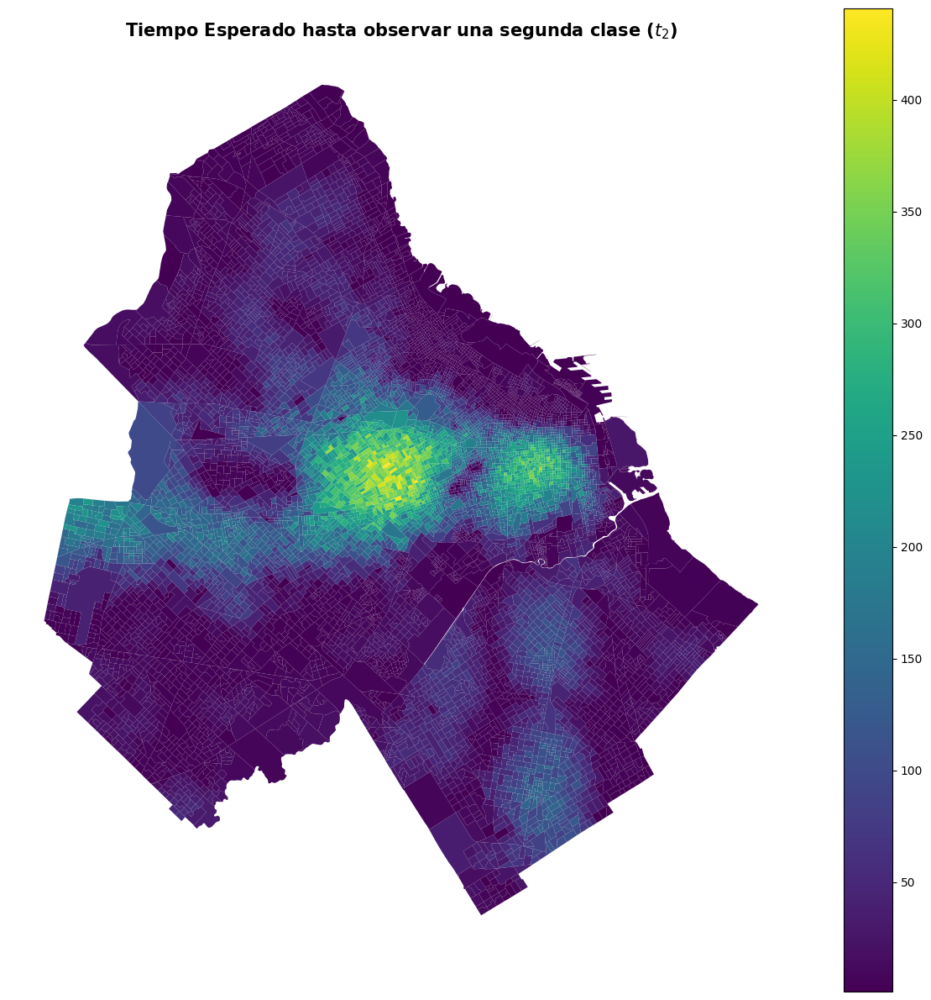

In [15]:
display(IPImage(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\mapa_t2.png"))

In [ ]:
fig, ax = plt.subplots(figsize=(12,12))

mapa_resultados.plot(column="t3",cmap="viridis",legend=True,ax=ax,edgecolor="none")
ax.set_title(r"Tiempo esperado hasta observar las tres clases ($t_3$)",fontsize=15,fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

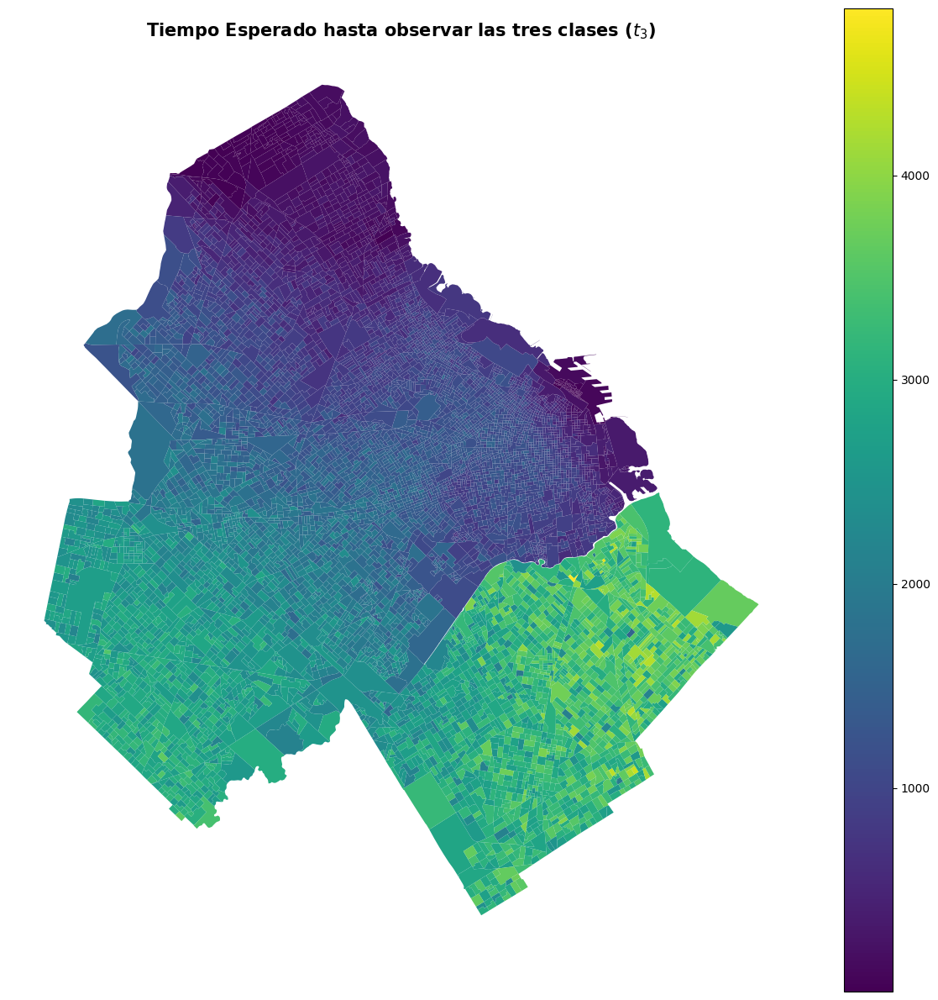

In [16]:
display(IPImage(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\mapa_t3.png"))

In [ ]:
fig, ax = plt.subplots(figsize=(12,12))

mapa_resultados.plot(column="no_alcanzo_3",cmap="cividis",vmin=0,vmax=1,legend=True,ax=ax,edgecolor="none")
ax.set_title("Proporción de caminatas que no alcanzan las tres clases",fontsize=15,fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

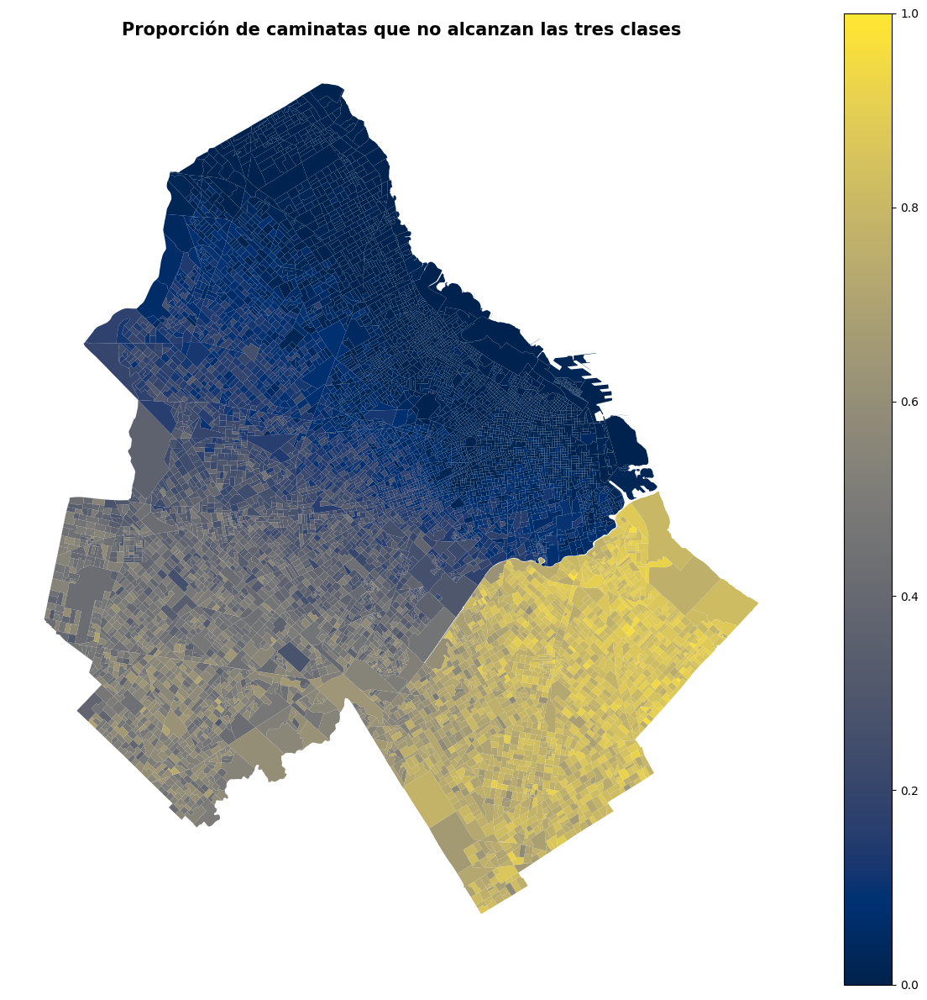

In [17]:
display(IPImage(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\mapa_no_alcanzo_3_clases.png"))

In [32]:
componentes_por_nse = []
for clase in clases_orden:
    nodos_clase = [nodo for nodo in G.nodes() if clases[nodo] == clase]
    subgrafo_clase = G.subgraph(nodos_clase).copy()
    componentes = sorted(nx.connected_components(subgrafo_clase),key=len,reverse=True )
    for numero_componente, componente in enumerate(componentes,start=1):
        identificador = (f"NSE_{clase}_C{numero_componente}")
        tamano = len(componente)
        for nodo in componente:
            componentes_por_nse.append(
                {
                    "nodo": nodo,
                    "clase_inicial": clase,
                    "componente_nse": identificador,
                    "numero_componente": numero_componente,
                    "tamanio_componente": tamano
                }
            )

componentes_por_nse_df = pd.DataFrame(componentes_por_nse)
resumen_componentes = (componentes_por_nse_df
    .groupby(["clase_inicial","componente_nse"],as_index=False)
    .agg(cantidad_radios=("nodo","nunique"))
    .sort_values(["clase_inicial","cantidad_radios"],ascending=[True,False]))
print(resumen_componentes.head())
print(resumen_componentes.groupby("clase_inicial")["componente_nse"].nunique()) #cuantas cc tengo por clase

resumen_componentes = (resumen_componentes.sort_values(["clase_inicial", "cantidad_radios"],ascending=[True, False]))
resumen_componentes["acumulado"] = (resumen_componentes.groupby("clase_inicial")["cantidad_radios"].cumsum()) #Suma cumulativa
totales_clase = (resumen_componentes.groupby("clase_inicial")["cantidad_radios"].transform("sum")) #tengo 1 registro por componente y una sola columna, y el valor es la cantidad total de radios por clase
resumen_componentes["proporcion_acumulada"] = (resumen_componentes["acumulado"] / totales_clase) #Hasta las n cc mas grandes, cuantos radios en % tengo cubiertos dentro de una clase?
print(resumen_componentes.head())
display(resumen_componentes.loc[resumen_componentes["proporcion_acumulada"] <= 0.90]) #para ver en cuantas componentes se alcanza el x% para cada clase, en este caso el 90% (<= 90% )

    clase_inicial componente_nse  cantidad_radios
0               2       NSE_2_C1              502
11              2       NSE_2_C2              392
22              2       NSE_2_C3              202
33              2       NSE_2_C4              140
44              2       NSE_2_C5               57
clase_inicial
2    95
3    80
4    71
Name: componente_nse, dtype: int64
    clase_inicial componente_nse  cantidad_radios  acumulado  \
0               2       NSE_2_C1              502        502   
11              2       NSE_2_C2              392        894   
22              2       NSE_2_C3              202       1096   
33              2       NSE_2_C4              140       1236   
44              2       NSE_2_C5               57       1293   

    proporcion_acumulada  
0               0.291860  
11              0.519767  
22              0.637209  
33              0.718605  
44              0.751744  


,clase_inicial,componente_nse,cantidad_radios,acumulado,proporcion_acumulada
0,2,NSE_2_C1,502,502,0.291860
11,2,NSE_2_C2,392,894,0.519767
22,2,NSE_2_C3,202,1096,0.637209
33,2,NSE_2_C4,140,1236,0.718605
44,2,NSE_2_C5,57,1293,0.751744
55,2,NSE_2_C6,53,1346,0.782558
66,2,NSE_2_C7,52,1398,0.812791
77,2,NSE_2_C8,35,1433,0.833140
1,2,NSE_2_C10,28,1461,0.849419
88,2,NSE_2_C9,28,1489,0.865698


In [33]:
componentes_relevantes = ( [f"NSE_2_C{i}" for i in range(1, 6)] + [f"NSE_3_C{i}" for i in range(1, 3)] + [f"NSE_4_C{i}" for i in range(1, 7)]) #2 cc para nse medio, 5 cc para nse bajo, 6 cc para nse alto
componentes_por_nse_df["componente_analisis"] = (componentes_por_nse_df["componente_nse"].where(componentes_por_nse_df["componente_nse"].isin(componentes_relevantes),"Otras componentes"))
resumen_visualizacion = (componentes_por_nse_df.groupby(["clase_inicial","componente_analisis"],as_index=False)
                        .agg(cantidad_radios=("nodo","nunique")).sort_values(["clase_inicial","cantidad_radios"],ascending=[True,False]))
display(resumen_visualizacion)

,clase_inicial,componente_analisis,cantidad_radios
0,2,NSE_2_C1,502
5,2,Otras componentes,427
1,2,NSE_2_C2,392
2,2,NSE_2_C3,202
3,2,NSE_2_C4,140
4,2,NSE_2_C5,57
6,3,NSE_3_C1,5330
7,3,NSE_3_C2,1073
8,3,Otras componentes,151
9,4,NSE_4_C1,176


In [ ]:
radios_componentes = UF.radios_estudio.merge(componentes_por_nse_df, left_on="codigo", right_on="nodo", how="left")
componentes_por_clase = {2:[f"NSE_2_C{i}" for i in range(1,6)], 3: [f"NSE_3_C{i}" for i in range(1,3)], 4: [f"NSE_4_C{i}" for i in range(1,7)]}
componentes_relevantes = [componente for componentes_clase in componentes_por_clase.values() for componente in componentes_clase]
colores_componentes = {
    # NSE bajo: azules
    "NSE_2_C1": "#08306B","NSE_2_C2": "#08519C","NSE_2_C3": "#0000CD","NSE_2_C4": "#4292C6","NSE_2_C5": "#9ECAE1",
    # NSE medio: marrones
    "NSE_3_C1": "#6F3325","NSE_3_C2": "#B8735C",
    # NSE alto: verdes
    "NSE_4_C1": "#00441B","NSE_4_C2": "#006D2C","NSE_4_C3": "#238B45","NSE_4_C4": "#41AB5D","NSE_4_C5": "#74C476","NSE_4_C6": "#9DD295"
}
nombres_componentes = {"NSE_2_C1": "La Matanza - Sudoeste","NSE_2_C2": "Zona Sur - Oeste","NSE_2_C3": "San Martin","NSE_2_C4": "Zona Sur - Sudeste","NSE_2_C5": "CABA - Soldati",
    "NSE_3_C1": "CABA - AMBA","NSE_3_C2": "Zona Sur","NSE_4_C1": "Recoleta - Palermo","NSE_4_C2": "Palermo - Nuñez","NSE_4_C3": "Colegiales","NSE_4_C4": "San Isidro","NSE_4_C5": "Vicente Lopez","NSE_4_C6": "Nuñez"}

fig, ax = plt.subplots(figsize=(15, 15))
radios_no_seleccionados = radios_componentes.loc[~radios_componentes["componente_nse"].isin(componentes_relevantes)]
radios_no_seleccionados.plot(ax=ax,facecolor="#D9D9D9",edgecolor="white",linewidth=0.04)
for componente in componentes_relevantes:
  radios_componente = radios_componentes.loc[radios_componentes["componente_nse"] == componente]
  radios_componente.plot(ax=ax,facecolor=colores_componentes[componente],edgecolor="white",linewidth=0.08)

ax.set_title("Principales componentes conexas por NSE",fontsize=17,fontweight="bold")
ax.set_axis_off()
elementos_leyenda = []

for clase, nombre_clase in [(2, "NSE bajo"),(3, "NSE medio"),(4, "NSE alto")]:
  elementos_leyenda.append(Patch(facecolor="none",edgecolor="none",label=nombre_clase))
  for componente in componentes_por_clase[clase]:
    cantidad = (radios_componentes["componente_nse"] == componente).sum()
    nombre_visible = nombres_componentes.get(componente,componente)
    elementos_leyenda.append(Patch(facecolor=colores_componentes[componente],edgecolor="none",label=f" {nombre_visible} (n={cantidad})"))

elementos_leyenda.append(Patch(facecolor="#D9D9D9",edgecolor="none",label="Componentes no seleccionadas"))
ax.legend(handles=elementos_leyenda,title="Componentes conexas",bbox_to_anchor=(1.01, 1),loc="upper left",fontsize=9,title_fontsize=11,frameon=True)
plt.tight_layout()
plt.show()

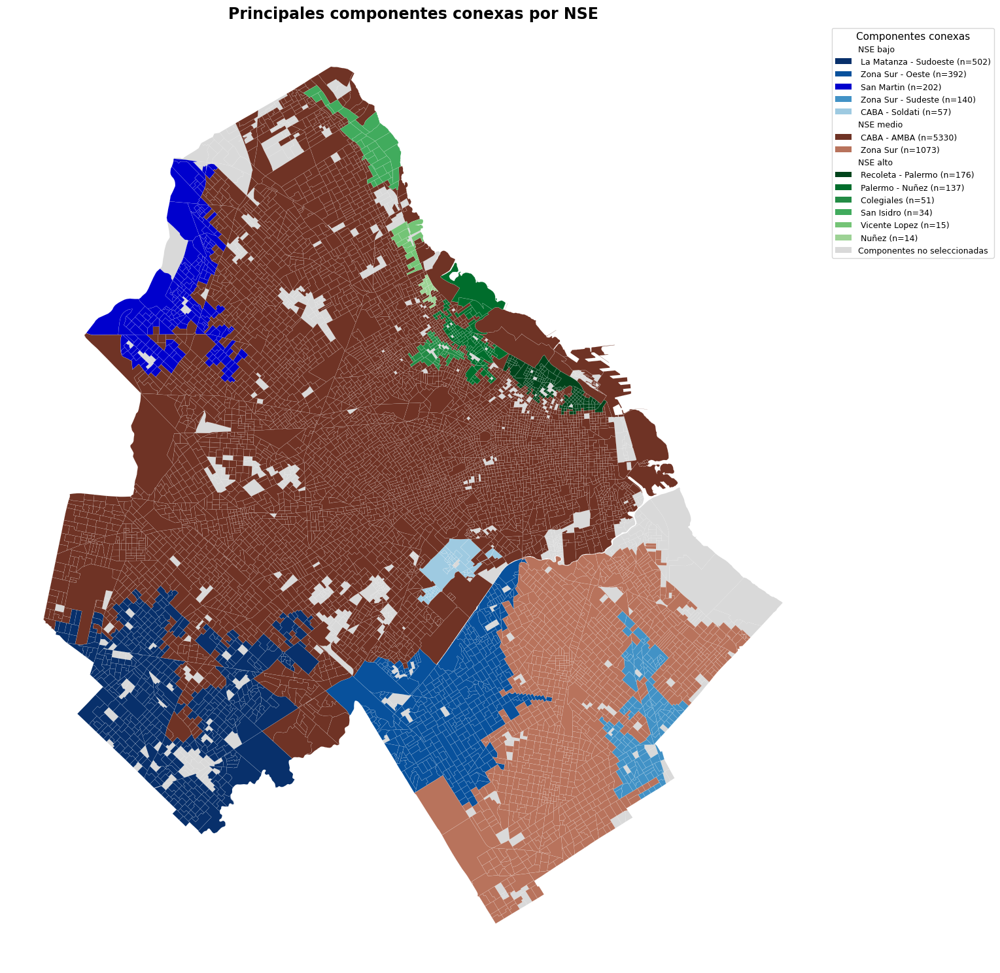

In [18]:
display(IPImage(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\nse_cc.png"))

In [ ]:
nombres_componentes = {
    # NSE bajo
    "NSE_2_C1": "La Matanza - Sudoeste","NSE_2_C2": "Zona Sur - Oeste","NSE_2_C3": "San Martín","NSE_2_C4": "Zona Sur - Sudeste","NSE_2_C5": "CABA - Soldati",
    # NSE medio
    "NSE_3_C1": "CABA - AMBA","NSE_3_C2": "Zona Sur",
    # NSE alto
    "NSE_4_C1": "Recoleta - Palermo","NSE_4_C2": "Palermo - Núñez","NSE_4_C3": "Colegiales","NSE_4_C4": "San Isidro","NSE_4_C5": "Vicente López","NSE_4_C6": "Núñez"}
componentes_por_nse_df["nombre_componente"] = (componentes_por_nse_df["componente_nse"].map(nombres_componentes))
display(componentes_por_nse_df.loc[componentes_por_nse_df["nombre_componente"].notna()].groupby(["clase_inicial","componente_nse","nombre_componente"],as_index=False).agg(cantidad_radios=("nodo", "nunique")))

,clase_inicial,componente_nse,nombre_componente,cantidad_radios
0,2,NSE_2_C1,La Matanza - Sudoeste,502
1,2,NSE_2_C2,Zona Sur - Oeste,392
2,2,NSE_2_C3,San Martín,202
3,2,NSE_2_C4,Zona Sur - Sudeste,140
4,2,NSE_2_C5,CABA - Soldati,57
5,3,NSE_3_C1,CABA - AMBA,5330
6,3,NSE_3_C2,Zona Sur,1073
7,4,NSE_4_C1,Recoleta - Palermo,176
8,4,NSE_4_C2,Palermo - Núñez,137
9,4,NSE_4_C3,Colegiales,51


In [74]:
resultados_componentes = (resultados_completos_df.merge(componentes_por_nse_df[["nodo","clase_inicial","componente_nse","numero_componente","tamanio_componente","nombre_componente"]],on=["nodo","clase_inicial"],how="left"))
resultados_componentes_principales = (resultados_componentes.loc[resultados_componentes["nombre_componente"].notna()].copy())
componentes_por_clase = {2: ["NSE_2_C1","NSE_2_C2","NSE_2_C3","NSE_2_C4","NSE_2_C5"],3: ["NSE_3_C1","NSE_3_C2"],4: ["NSE_4_C1","NSE_4_C2","NSE_4_C3","NSE_4_C4","NSE_4_C5","NSE_4_C6"]}
resumen_final_componentes = (resultados_componentes_principales.groupby(["clase_inicial","componente_nse","nombre_componente"],as_index=False)
                             .agg(cantidad_radios=("nodo","nunique"),t2_promedio=("t2","mean"),t2_mediana=("t2","median"),t2_desvio=("t2","std"),
                                  t3_promedio=("t3","mean"),t3_mediana=("t3","median"),t3_desvio=("t3","std"),
                                  no_alcanzo_3_promedio=("no_alcanzo_3","mean")))
display(resumen_final_componentes)

,clase_inicial,componente_nse,nombre_componente,cantidad_radios,t2_promedio,t2_mediana,t2_desvio,t3_promedio,t3_mediana,t3_desvio,no_alcanzo_3_promedio
0,2.0,NSE_2_C1,La Matanza - Sudoeste,502,12.699641,11.13,9.644716,2803.330291,2821.523148,278.117717,0.513347
1,2.0,NSE_2_C2,Zona Sur - Oeste,392,34.650918,35.70,21.217157,2697.277871,2679.537549,397.811363,0.680612
2,2.0,NSE_2_C3,San Martín,202,8.995743,7.70,5.732485,1130.726212,1185.471795,371.458974,0.126139
3,2.0,NSE_2_C4,Zona Sur - Sudeste,140,6.057714,5.62,3.434112,3360.816594,3363.494949,422.188067,0.833571
4,2.0,NSE_2_C5,CABA - Soldati,57,9.209123,8.76,5.032087,1405.272010,1377.742857,261.360608,0.269825
5,3.0,NSE_3_C1,CABA - AMBA,5330,109.209452,78.56,100.686752,1291.246679,1179.150815,647.765114,0.147111
6,3.0,NSE_3_C2,Zona Sur,1073,53.691277,44.28,38.496550,3238.857921,3251.666667,406.754908,0.803989
7,4.0,NSE_4_C1,Recoleta - Palermo,176,8.706477,8.47,4.767732,744.016397,764.430000,261.275825,0.003409
8,4.0,NSE_4_C2,Palermo - Núñez,137,5.260584,3.92,3.707791,965.285379,969.780000,146.224195,0.004088
9,4.0,NSE_4_C3,Colegiales,51,2.937647,2.58,1.062312,1033.039019,1029.120000,121.666995,0.004314


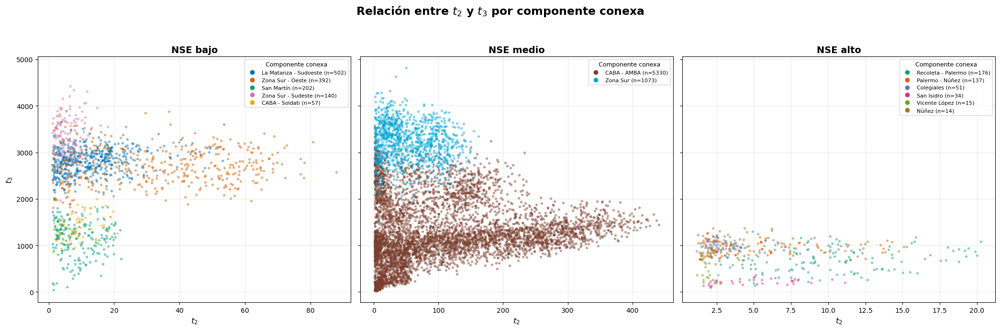

In [ ]:
colores_componentes = {
    "NSE_2_C1": "#0072B2",  "NSE_2_C2": "#D55E00",  "NSE_2_C3": "#009E73",  "NSE_2_C4": "#CC79A7",  "NSE_2_C5": "#E6AB02",  "NSE_3_C1": "#7A3E2D",  "NSE_3_C2": "#00A6D6",
    "NSE_4_C1": "#1B9E77",  "NSE_4_C2": "#D95F02",  "NSE_4_C3": "#7570B3", "NSE_4_C4": "#E7298A",  "NSE_4_C5": "#66A61E",  "NSE_4_C6": "#A6761D"}
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(21, 7),sharex=False,sharey=True)
for ax, clase in zip(axes,clases_orden):
    datos_clase = (resultados_componentes_principales.loc[resultados_componentes_principales["clase_inicial"] == clase].dropna(subset=["t2","t3"]).copy())
    elementos_leyenda = []
    for componente in componentes_por_clase[clase]:
        datos_componente = (datos_clase.loc[datos_clase["componente_nse"] == componente])
        color = colores_componentes[componente]
        nombre_visible = nombres_componentes[componente]
        ax.scatter(datos_componente["t2"],datos_componente["t3"],color=color,alpha=0.4,s=8)
        elementos_leyenda.append(Line2D([0],[0],marker="o",linestyle="None",markerfacecolor=color,markeredgecolor="none",markersize=7,label=(f"{nombre_visible} "f"(n={len(datos_componente)})")))
    ax.set_title(etiquetas_nse[clase],fontsize=14,fontweight="bold")
    ax.set_xlabel(r"$t_2$",fontsize=12)
    ax.grid(alpha=0.25)
    ax.legend(handles=elementos_leyenda,title="Componente conexa",fontsize=8,title_fontsize=9,loc="best",frameon=True)

axes[0].set_ylabel(r"$t_3$",fontsize=12)
fig.suptitle(r"Relación entre $t_2$ y $t_3$ por componente conexa",fontsize=17,fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

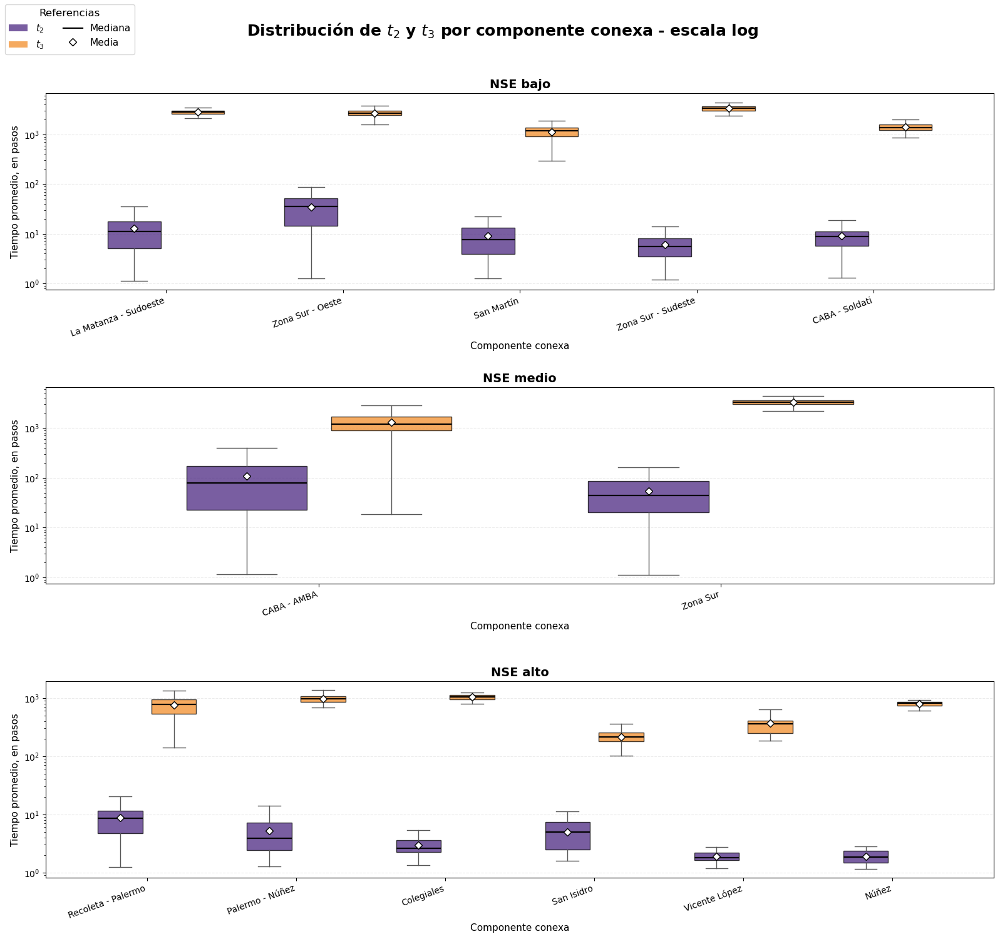

In [66]:
colores_objetivo = {"t2": "#4c2882","t3": "#F28E2B"}
desplazamiento = 0.18
ancho_caja = 0.30
fig, axes = plt.subplots(nrows=3,ncols=1,figsize=(16, 16),sharey=False)
for ax, clase in zip(axes,clases_orden):
    componentes_clase = componentes_por_clase[clase]
    posiciones = np.arange(len(componentes_clase))
    datos_t2 = [resultados_componentes_principales.loc[resultados_componentes_principales["componente_nse"] == componente,"t2"].dropna() for componente in componentes_clase]
    datos_t3 = [resultados_componentes_principales.loc[resultados_componentes_principales["componente_nse"] == componente,"t3"].dropna() for componente in componentes_clase]
    box_t2 = ax.boxplot(datos_t2,positions=posiciones - desplazamiento,widths=ancho_caja,patch_artist=True,showmeans=True,showfliers=False,
                        medianprops={"color": "black","linewidth": 1.6},meanprops={"marker": "D","markerfacecolor": "white","markeredgecolor": "black","markersize": 6},
                        whiskerprops={"color": "#555555","linewidth": 1},capprops={"color": "#555555","linewidth": 1})
    box_t3 = ax.boxplot(datos_t3,positions=posiciones + desplazamiento,widths=ancho_caja,patch_artist=True,showmeans=True,showfliers=False,
                        medianprops={"color": "black","linewidth": 1.6},meanprops={"marker": "D","markerfacecolor": "white","markeredgecolor": "black","markersize": 6},
                        whiskerprops={"color": "#555555","linewidth": 1},capprops={"color": "#555555","linewidth": 1})
    for caja in box_t2["boxes"]:
        caja.set_facecolor(colores_objetivo["t2"])
        caja.set_alpha(0.75)
    for caja in box_t3["boxes"]:
        caja.set_facecolor(colores_objetivo["t3"])
        caja.set_alpha(0.75)
    etiquetas_componentes = [nombres_componentes.get(componente,componente) for componente in componentes_clase]
    ax.set_xticks(posiciones)
    ax.set_xticklabels(etiquetas_componentes,fontsize=10,rotation=20,ha="right")
    ax.set_title(etiquetas_nse[clase],fontsize=14,fontweight="bold")
    ax.set_xlabel("Componente conexa",fontsize=11)
    ax.set_ylabel("Tiempo promedio, en pasos",fontsize=11)
    ax.grid(axis="y",linestyle="--",alpha=0.25)
    ax.set_yscale("log")

elementos_leyenda = [Patch(facecolor=colores_objetivo["t2"],alpha=0.75,label=r"$t_2$"),
                     Patch(facecolor=colores_objetivo["t3"],alpha=0.75,label=r"$t_3$"),
                     Line2D([0],[0],color="black",linewidth=1.6,label="Mediana"),
                     Line2D([0],[0],marker="D",markerfacecolor="white",markeredgecolor="black",linestyle="None",markersize=6,label="Media")]
fig.legend(handles=elementos_leyenda,title="Referencias",loc="upper left",ncol=2,fontsize=11,title_fontsize=12,frameon=True)
fig.suptitle(r"Distribución de $t_2$ y $t_3$ por componente conexa - escala log",fontsize=18,fontweight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 0.96],h_pad=2.5)
plt.show()

In [26]:
#Busco correr todo pero con los puentes CABA-Zona Sur que antes no estaban en la red de aristas.


aristas_nuevas = [
    ('020281911','060350102'), #Autopista Buenos Aires - La Plata
    ('020281910','060350901'), #Puente Nicolás Avellaneda
    ('020282311','060351001'), #Puente Pueyrredon y Puente Viejo
    ('020282312','060351101'), #Puente Bosch
    ('020282312','060353401'), #Puente Bosch
    ('020282309','060351101'), #Puente Bosch
    ('020282309','060353401'), #Puente Bosch
    ('020281109','060353408'), #Puente Victorino de la Plaza
    ('020281107','060353408'), #Puente Victorino de la Plaza
    ('020281109','060353501'), #Puente Victorino de la Plaza
    ('020281107','060353501'), #Puente Victorino de la Plaza
    ('020280902','064340113'), #Puente Ezequiel Demonty
    ('020280114','064342201'), #Puente Ezequiel Demonty
    ('020561301','064342601'), #Puente Olimpico Ribera Sur
    ('020561207','064900115'), #Puente La Noria
    ('020561207','064903701')  #Puente La Noria
]

G_nueva = G.copy()
G_nueva.add_edges_from(aristas_nuevas)

In [27]:
#Corrida para todos los radios censales, incluyendo los nuevos
TODOS_LOS_RADIOS_NUEVOS = list(G_nueva.nodes())
resultados_completos_nueva = []

for i, radio in enumerate(TODOS_LOS_RADIOS_NUEVOS):
    if i % 100 == 0:
        print(f"{i}/{len(TODOS_LOS_RADIOS_NUEVOS)}")

    resultado_nuevo, _ = UF.estimar_tiempos_nodo(
        G=G_nueva,
        clases=clases,
        nodo_inicial=radio,
        numero_simulaciones=50,
        max_pasos=5000,
        semilla=123 + i,
        nombre_configuracion="amba_caba_5000_pasos_50_sim_con_puentes"
    )

    resultados_completos_nueva.append(resultado_nuevo)

resultados_completos_df_nuevos = pd.DataFrame(resultados_completos_nueva)

0/8847
100/8847
200/8847
300/8847
400/8847
500/8847
600/8847
700/8847
800/8847
900/8847
1000/8847
1100/8847
1200/8847
1300/8847
1400/8847
1500/8847
1600/8847
1700/8847
1800/8847
1900/8847
2000/8847
2100/8847
2200/8847
2300/8847
2400/8847
2500/8847
2600/8847
2700/8847
2800/8847
2900/8847
3000/8847
3100/8847
3200/8847
3300/8847
3400/8847
3500/8847
3600/8847
3700/8847
3800/8847
3900/8847
4000/8847
4100/8847
4200/8847
4300/8847
4400/8847
4500/8847
4600/8847
4700/8847
4800/8847
4900/8847
5000/8847
5100/8847
5200/8847
5300/8847
5400/8847
5500/8847
5600/8847
5700/8847
5800/8847
5900/8847
6000/8847
6100/8847
6200/8847
6300/8847
6400/8847
6500/8847
6600/8847
6700/8847
6800/8847
6900/8847
7000/8847
7100/8847
7200/8847
7300/8847
7400/8847
7500/8847
7600/8847
7700/8847
7800/8847
7900/8847
8000/8847
8100/8847
8200/8847
8300/8847
8400/8847
8500/8847
8600/8847
8700/8847
8800/8847


In [30]:
datos_largos_nuevos = pd.concat([resultados_completos_df_nuevos[["nodo","clase_inicial","t2"]].rename(columns={"t2": "tiempo"}).assign(objetivo="t2",x=2),
                          resultados_completos_df_nuevos[["nodo","clase_inicial","t3"]].rename(columns={"t3": "tiempo"}).assign(objetivo="t3",x=3)],
                          ignore_index=True)         

In [ ]:
resumen_largo = (resultados_completos_df_nuevos.groupby("clase_inicial")[["t2","t3","no_alcanzo_3"]].agg(["mean","median","std","min","max"]))
resumen_largo #El mean y median de no_alcanzó_t3 en el experimento anterior sin las nuevas aristas es 0.48 y 0.52 respectivamente, en este bajan a 0.36 y 0.40.

t2                                          t3  \
                    mean median        std  min     max         mean   
clase_inicial                                                          
2.0            13.970837   7.97  15.127458  1.0   74.58  2167.591849   
3.0            97.537818  64.85  95.744328  1.0  460.56  1545.540420   
4.0             5.081291   3.20   4.452739  1.0   23.12   756.246699   

                                                           no_alcanzo_3  \
                    median         std    min          max         mean   
clase_inicial                                                             
2.0            2410.274557  800.728508   4.98  3538.576923     0.365837   
3.0            1386.802365  764.077511  19.12  3513.840000     0.201831   
4.0             848.520000  345.385832   8.92  1420.840000     0.002723   

                                           
              median       std  min   max  
clase_inicial                              
2.0             0.40  0.162287  0.0  0.68  
3.0             0.16  0.181645  0.0  0.70  
4.0             0.00  0.007906  0.0  0.04

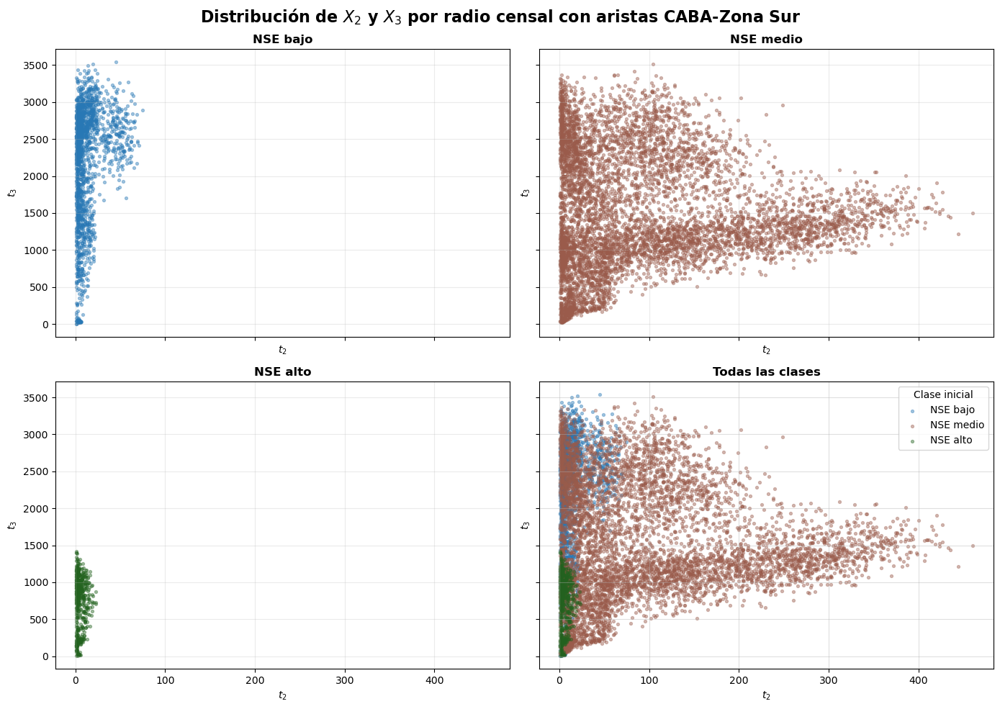

In [ ]:
#Recreo los graficos anteriores  
resultados_plot_completos_nuevos= resultados_completos_df_nuevos.copy()
resultados_plot_completos_nuevos["clase_nombre"] = (resultados_plot_completos_nuevos["clase_inicial"].astype(int).map(etiquetas_nse))

fig, axes = plt.subplots(2, 2,figsize=(14, 10),sharex=True,sharey=True)
for ax, clase in zip( [axes[0,0], axes[0,1], axes[1,0]],clases_orden):
    subset = resultados_plot_completos_nuevos.loc[resultados_plot_completos_nuevos["clase_inicial"] == clase]
    ax.scatter(
        subset["t2"],
        subset["t3"],
        alpha=0.4,
        s=8,
        color=colores[clase])
    ax.set_title(etiquetas_nse[clase],fontweight="bold")
    ax.set_xlabel(r"$t_2$")
    ax.set_ylabel(r"$t_3$")
    ax.grid(alpha=0.25)

# Panel inferior derecho: todos juntos
ax = axes[1,1]
for clase in clases_orden:
    subset = resultados_plot_completos_nuevos.loc[resultados_plot_completos_nuevos["clase_inicial"] == clase]
    ax.scatter(
        subset["t2"],
        subset["t3"],
        alpha=0.4,
        s=8,
        color=colores[clase],
        label=etiquetas_nse[clase]
    )

ax.set_title("Todas las clases",fontweight="bold")
ax.set_xlabel(r"$t_2$")
ax.set_ylabel(r"$t_3$")
ax.grid(alpha=0.4)
ax.legend(title="Clase inicial")
fig.suptitle("Distribución de $X_2$ y $X_3$ por radio censal con aristas CABA-Zona Sur",fontsize=16,fontweight="bold")

plt.tight_layout()
plt.show()
#Hay puntos en la corrida del algoritmo sin las aristas caba-Zona Sur que alcanzan el maximo t3 en mas de 4 mil pasos, acá el maximo del grafico llega a 3.500 ...

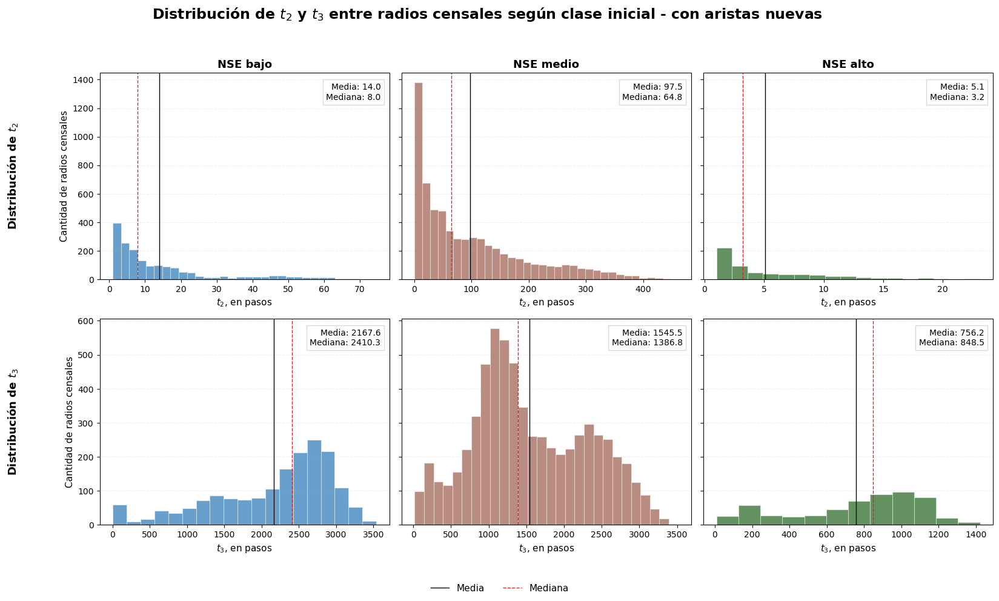

In [37]:
fig, axes = plt.subplots(nrows=2,ncols=3,figsize=(17, 10),sharex=False,sharey="row")
for columna, clase in enumerate(clases_orden):

    datos_clase_comp_nuevos= resultados_plot_completos_nuevos.loc[resultados_plot_completos_nuevos["clase_inicial"] == clase]
    valores_t2_nuevo = (datos_clase_comp_nuevos["t2"].dropna().to_numpy())
    media_t2_nuevo = np.mean(valores_t2_nuevo)
    mediana_t2_nuevo = np.median(valores_t2_nuevo)

    ax_x2 = axes[0, columna]
    ax_x2.hist(valores_t2_nuevo,bins="auto",color=colores[clase],alpha=0.70,edgecolor="white",linewidth=0.5)
    ax_x2.axvline(media_t2_nuevo,color="black",linestyle="-",linewidth=1) #Media
    ax_x2.axvline(mediana_t2_nuevo,color="#D62728",linestyle="--",linewidth=1) #Mediana
    ax_x2.set_title(etiquetas_nse[clase],fontsize=13,fontweight="bold")
    ax_x2.set_xlabel(r"$t_2$, en pasos",fontsize=11)
    ax_x2.grid(axis="y",linestyle="--",alpha=0.20)
    ax_x2.text(0.97,0.95,(f"Media: {media_t2_nuevo:.1f}\n" f"Mediana: {mediana_t2_nuevo:.1f}"),
        transform=ax_x2.transAxes,ha="right",va="top",fontsize=10,
        bbox={"facecolor": "white","edgecolor": "lightgray","alpha": 0.85})
    
    if columna == 0:
        ax_x2.set_ylabel("Cantidad de radios censales",fontsize=11)

    valores_t3_nuevo = (datos_clase_comp_nuevos["t3"].dropna().to_numpy())
    media_t3_nuevo = np.mean(valores_t3_nuevo)
    mediana_t3_nuevo = np.median(valores_t3_nuevo)

    ax_x3 = axes[1, columna]
    ax_x3.hist(valores_t3_nuevo,bins="auto",color=colores[clase],alpha=0.70,edgecolor="white",linewidth=0.5)
    ax_x3.axvline(media_t3_nuevo,color="black",linestyle="-",linewidth=1)
    ax_x3.axvline(mediana_t3_nuevo,color="#D62728",linestyle="--",linewidth=1)
    ax_x3.set_xlabel(r"$t_3$, en pasos",fontsize=11)
    ax_x3.grid(axis="y",linestyle="--",alpha=0.20)
    ax_x3.text(0.97,0.95,(f"Media: {media_t3_nuevo:.1f}\n" f"Mediana: {mediana_t3_nuevo:.1f}"),
        transform=ax_x3.transAxes,ha="right",va="top",fontsize=10,
        bbox={"facecolor": "white","edgecolor": "lightgray","alpha": 0.85})
    
    if columna == 0:
        ax_x3.set_ylabel("Cantidad de radios censales",fontsize=11)

axes[0, 0].annotate(r"Distribución de $t_2$", xy=(-0.30, 0.5),xycoords="axes fraction",rotation=90,ha="center",va="center",fontsize=13,fontweight="bold")
axes[1, 0].annotate(r"Distribución de $t_3$", xy=(-0.30, 0.5),xycoords="axes fraction",rotation=90,ha="center",va="center",fontsize=13,fontweight="bold")

elementos_leyenda = [Line2D([0],[0],color="black",linestyle="-",linewidth=1,label="Media"),
                     Line2D([0],[0],color="#D62728",linestyle="--",linewidth=1,label="Mediana")]

fig.legend(handles=elementos_leyenda,loc="lower center",ncol=2,fontsize=11,frameon=False)
fig.suptitle(r"Distribución de $t_2$ y $t_3$ entre radios censales según clase inicial - con aristas nuevas",fontsize=17,fontweight="bold")

plt.tight_layout(rect=[0.04, 0.06, 1, 0.95])
plt.show()

In [ ]:
#Voy a los mapas directo.
mapa_resultados = UF.radios_estudio.merge(resultados_completos_df_nuevos,left_on="codigo",right_on="nodo",how="inner")
fig,ax = plt.subplots(figsize=(12,12))
mapa_resultados.plot(column="t2",cmap="viridis",legend=True,ax=ax,edgecolor="none",vmin=1,vmax=440.84)
ax.set_title(r"Tiempo Esperado hasta observar una segunda clase ($t_2$)", fontsize=15,fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

fig,ax = plt.subplots(figsize=(12,12))
mapa_resultados.plot(column="t3",cmap="viridis",legend=True,ax=ax,edgecolor="none",vmin=3.34,vmax=4818)
ax.set_title(r"Tiempo Esperado hasta observar las tres clases ($t_3$)", fontsize=15,fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

fig,ax = plt.subplots(figsize=(12,12))
mapa_resultados.plot(column="no_alcanzo_3",cmap="cividis",vmin=0,vmax=1,legend=True,ax=ax,edgecolor="none")
ax.set_title(r"Proporción de caminatas que no alcanzan las tres clases", fontsize=15,fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

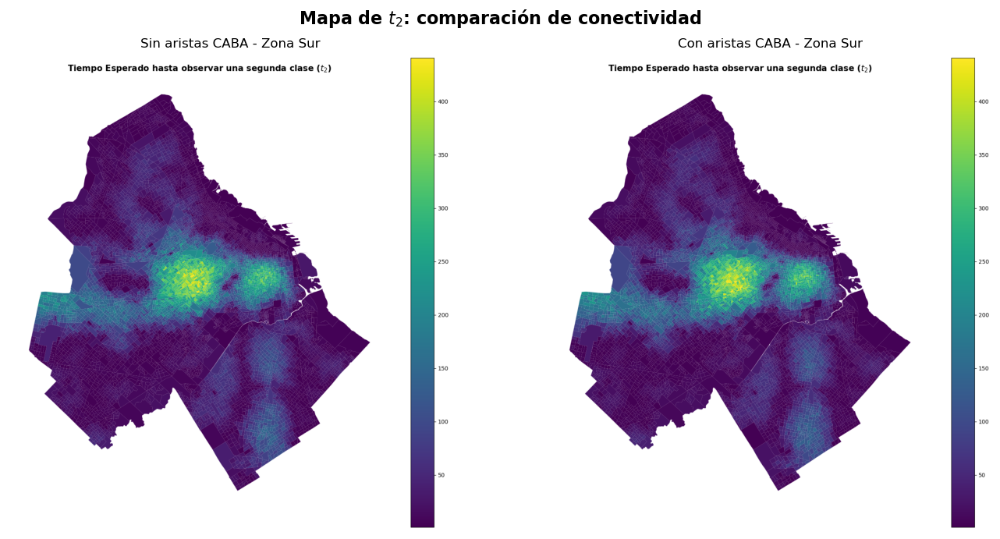

In [19]:
#Muestro los mapas resultantes de la celda anterior, como el codigo de la celda anterior lo ejecuté en otra compy me guardé y envié a esta compu la imagen como archivo. 
#Muestro los mapas que muestran una misma metrica para los 2 experimentos uno al lado del otro.

img_con_aristas_nuevast2 = PILImage.open(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\t2_con_aristas_caba_zona_sur.png")
img_sin_aristas_nuevast2 = PILImage.open(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\mapa_t2.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(img_sin_aristas_nuevast2)
axes[0].set_title("Sin aristas CABA - Zona Sur")
axes[0].axis("off")
axes[1].imshow(img_con_aristas_nuevast2)
axes[1].set_title("Con aristas CABA - Zona Sur")
axes[1].axis("off")

plt.suptitle(r"Mapa de $t_2$: comparación de conectividad",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

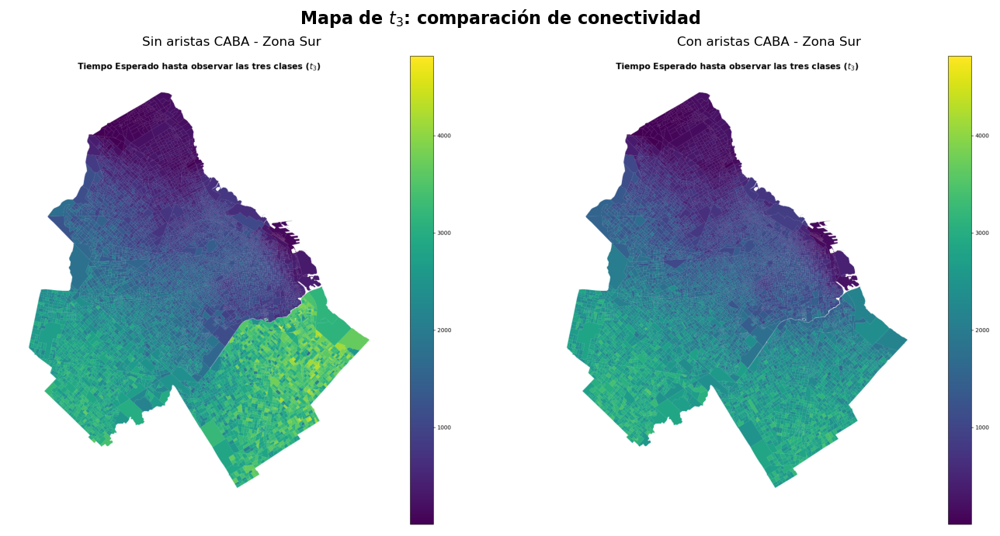

In [20]:
img_con_aristas_nuevast3 = PILImage.open(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\t3_con_aristas_caba_zona_sur.png")
img_sin_aristas_nuevast3 = PILImage.open(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\mapa_t3.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(img_sin_aristas_nuevast3)
axes[0].set_title("Sin aristas CABA - Zona Sur")
axes[0].axis("off")
axes[1].imshow(img_con_aristas_nuevast3)
axes[1].set_title("Con aristas CABA - Zona Sur")
axes[1].axis("off")

plt.suptitle(r"Mapa de $t_3$: comparación de conectividad",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

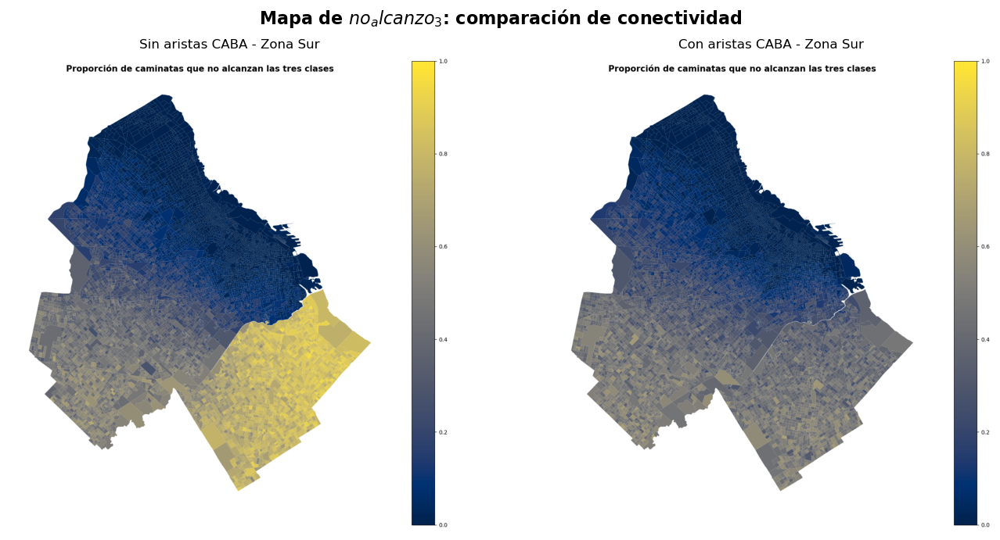

In [21]:
img_con_aristas_nuevas_no_alcanzo_3 = PILImage.open(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\no_alcanzo_3_con_aristas_caba_zona_sur.png")
img_sin_aristas_nuevas_no_alcanzo_3 = PILImage.open(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\mapa_no_alcanzo_3_clases.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(img_sin_aristas_nuevas_no_alcanzo_3)
axes[0].set_title("Sin aristas CABA - Zona Sur")
axes[0].axis("off")
axes[1].imshow(img_con_aristas_nuevas_no_alcanzo_3)
axes[1].set_title("Con aristas CABA - Zona Sur")
axes[1].axis("off")

plt.suptitle(r"Mapa de $no_alcanzo_3$: comparación de conectividad",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

In [153]:
#Miro el mapa de NSE por radio censal pero solo considerando jefes de hogar de edad +30
jefes_hogar_mas_30 = censo_data.loc[censo_data["p01"] == 1 & (censo_data["edad"] >= 30)].copy()
tabla_nse_jefes_mas_30 = pd.concat([jefes_hogar_mas_30["NSE"].value_counts(dropna=False).sort_index().rename("cantidad"),
                            jefes_hogar_mas_30["NSE"].value_counts(dropna=False,normalize=True).sort_index().round(2).rename("porcentaje")],axis=1)
tabla_nse_jefes_mas_30 = tabla_nse_jefes_mas_30.join(tabla_nse_jefes, lsuffix='_mas_30', rsuffix='_general')
print(tabla_nse_jefes_mas_30) #Las proporciones son similares

tabla_nse_radio_mas_30 = (jefes_hogar_mas_30.groupby(["codigo", "NSE"],dropna=False).size().reset_index(name="hogares"))
print(tabla_nse_radio_mas_30.head(10))

nse_mayoritario_mas_30 = (tabla_nse_radio_mas_30.sort_values(["codigo", "hogares"],ascending=[True, False]).drop_duplicates("codigo")[["codigo", "NSE"]].rename(columns={"NSE": "NSE_radio_mas_30"})) 
#Al ordenar, dentro de cada radio censal, de mayor a menor el NSE segun cantidad de hogares, y luego se queda con el primer registro por radio, me guarda el par (codigo, NSE mayoritario)
print(nse_mayoritario_mas_30["NSE_radio_mas_30"].value_counts()) #Con el filtro de edad me aparecen dos radios con NSE muy bajo como predominante, y uno en el que hay emnpate NSE muy  bajo vs bajo

comparacion_nse_mas_30 = (nse_mayoritario.merge(nse_mayoritario_mas_30,on="codigo",how="inner"))
comparacion_nse_mas_30["cambio"] = (comparacion_nse_mas_30["NSE_radio"] != comparacion_nse_mas_30["NSE_radio_mas_30"])

print("Radios que cambian:",comparacion_nse_mas_30["cambio"].sum())
print("Porcentaje que cambia:",round(100 * comparacion_nse_mas_30["cambio"].mean(),2),"%")

#Me quedo con la distribucion completa, por si la necesito despues
nse_pivot_mas_30 = tabla_nse_radio_mas_30.pivot(index="codigo",columns="NSE",values="hogares").fillna(0)

     cantidad_mas_30  porcentaje_mas_30  cantidad_general  porcentaje_general
NSE                                                                          
1.0           192788               0.07            205168                0.07
2.0           691601               0.26            758659                0.25
3.0          1241852               0.46           1439876                0.48
4.0           555730               0.21            598775                0.20
NaN            25599               0.01             27584                0.01
      codigo  NSE  hogares
0  020070101  1.0        7
1  020070101  2.0       15
2  020070101  3.0       39
3  020070101  4.0       17
4  020070101  NaN        3
5  020070201  1.0       22
6  020070201  2.0       80
7  020070201  3.0       63
8  020070201  4.0       15
9  020070202  1.0       24
NSE_radio_mas_30
3.0    6169
2.0    1865
4.0     810
1.0       3
Name: count, dtype: int64
Radios que cambian: 418
Porcentaje que cambia: 4.72 %


In [ ]:
#Me fijo si hay empates.
tabla_nse_radio_mas_30["max_hogares"] = (tabla_nse_radio_mas_30.groupby("codigo")["hogares"].transform("max"))
empates = (tabla_nse_radio_mas_30.loc[tabla_nse_radio_mas_30["hogares"] == tabla_nse_radio_mas_30["max_hogares"]].groupby("codigo").size())
print((empates > 1).sum()) #Hay 41 empates, sigue siendo poco y casi lo mismo que el caso de antes, donde nos quedamos con todos los jefes de hogar (en ese caso habia 37 empates)

tabla_intermedia_empates_mas_30 = tabla_nse_radio_mas_30[tabla_nse_radio_mas_30["hogares"]==tabla_nse_radio_mas_30["max_hogares"]].copy()
tabla_intermedia_empates_mas_30["cantidad_clases_mayoritarias"] = tabla_intermedia_empates_mas_30.groupby("codigo")["codigo"].transform("count")
tabla_empates_mas_30 = tabla_intermedia_empates_mas_30[tabla_intermedia_empates_mas_30["cantidad_clases_mayoritarias"] > 1]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(tabla_empates_mas_30)

41
          codigo  NSE  hogares  max_hogares  cantidad_clases_mayoritarias
80     020070218  2.0       65           65                             2
81     020070218  3.0       65           65                             2
476    020070910  3.0       92           92                             2
477    020070910  4.0       92           92                             2
1519   020072707  2.0       90           90                             2
1520   020072707  3.0       90           90                             2
1680   020073008  2.0       64           64                             2
1681   020073008  3.0       64           64                             2
4877   020281906  2.0      148          148                             2
4878   020281906  3.0      148          148                             2
8497   020491709  2.0       20           20                             2
8498   020491709  3.0       20           20                             2
12030  020770402  3.0      137     

In [ ]:
#Genero nuevo mapa NSE
radios_nse = UF.radios_estudio.merge(nse,on="codigo",how="left")
colores_fijos = {
    "Clase muy baja": "#FFFF00", #amarillo fluor, porque son pocos radios
    "Clase baja": "#2878B5", # azul oscuro
    "Clase media": "#9A5B4B", # marrón
    "Clase alta": "#23631F" # verde oscuro
}
mapa_nse = {1.0:"Clase muy baja",2.0:"Clase baja", 3.0:"Clase media", 4.0:"Clase alta"}
radios_nse["NSE_radio_label"] = radios_nse["NSE_radio_mas_30"].map(mapa_nse)
radios_nse["color"] = radios_nse["NSE_radio_label"].map(colores_fijos)

fig, ax = plt.subplots(figsize=(14, 14))
radios_nse.plot(ax=ax,color=radios_nse["color"],edgecolor="white",linewidth=0.10)
ax.set_title("Radios censales por NSE calculado - Jefes >= 30 años",fontsize=32,fontweight="bold")
ax.set_axis_off()

leyenda = [
    Patch(facecolor=colores_fijos["Clase muy baja"], label="Clase muy baja"),
    Patch(facecolor=colores_fijos["Clase baja"], label="Clase baja"),
    Patch(facecolor=colores_fijos["Clase media"], label="Clase media"),
    Patch(facecolor=colores_fijos["Clase alta"], label="Clase alta")
]

ax.legend(handles=leyenda,title="CABA y partidos",prop={'size': 22}, title_fontsize=26 )
plt.tight_layout()
plt.show()

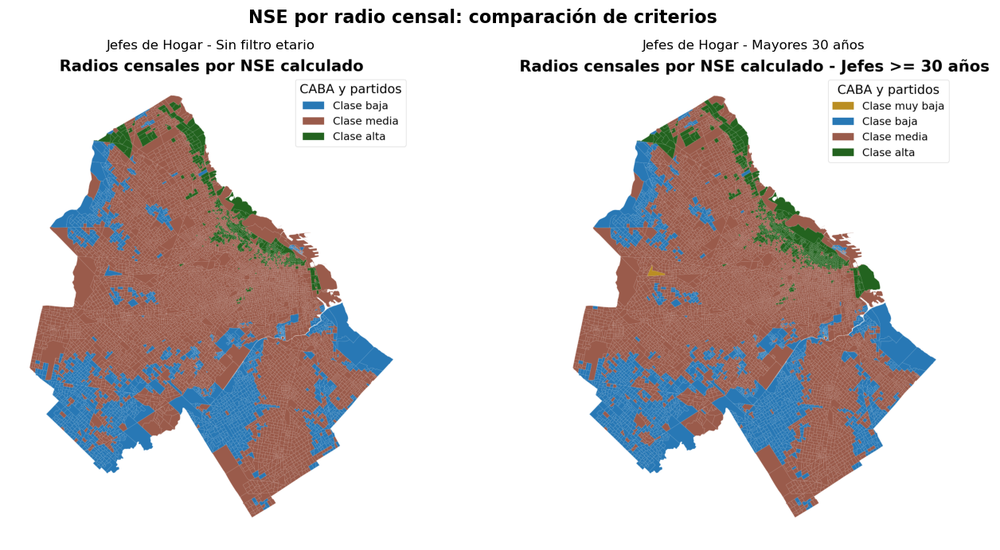

In [ ]:
NSE_radio = PILImage.open(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\RadiosCensalesNSE.png")
NSE_mas_30 = PILImage.open(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\nse_mas_30.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(NSE_radio)
axes[0].set_title("Jefes de Hogar - Sin filtro etario")
axes[0].axis("off")
axes[1].imshow(NSE_mas_30)
axes[1].set_title("Jefes de Hogar - Mayores 30 años")
axes[1].axis("off")

plt.suptitle(r"NSE por radio censal: comparación de criterios",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show() #Los veo similares en general

In [165]:
#Me fijo el mapa resultante de hacer NSE * miembros hogar en lugar de solo tomar jefes de hogar y ver NSE
jefes_ponderados = censo_data.loc[censo_data["p01"] == 1,["codigo", "NSE", "totpobh"]].copy()
tabla_nse_radio_ponderada = (jefes_ponderados.groupby(["codigo", "NSE"], dropna=False)["totpobh"].sum().reset_index(name="personas"))
#Igual que antes, ordeno dentro de un mismo radio los NSE por cantidad de personas en orden descendiente, y al eliminar duplicados por codigo me quedo con la primer fila por radio, que luego del orden establecido corresponderá al NSE modal
nse_mayoritario_ponderado = tabla_nse_radio_ponderada.sort_values(["codigo", "personas"],ascending=[True, False]).drop_duplicates("codigo")[["codigo", "NSE"]].rename(columns={"NSE": "NSE_radio_ponderado"})
print(nse_mayoritario_ponderado["NSE_radio_ponderado"].value_counts())

comparacion_nse_ponderados = (nse_mayoritario.merge(nse_mayoritario_ponderado,on="codigo",how="inner"))
comparacion_nse_ponderados["cambio"] = (comparacion_nse_ponderados["NSE_radio"] != comparacion_nse_ponderados["NSE_radio_ponderado"])

print("Radios que cambian:",comparacion_nse_ponderados["cambio"].sum())
print("Porcentaje que cambia:",round(100 * comparacion_nse_ponderados["cambio"].mean(),2),"%")

NSE_radio_ponderado
3.0    6347
2.0    1749
4.0     749
1.0       2
Name: count, dtype: int64
Radios que cambian: 381
Porcentaje que cambia: 4.31 %


In [161]:
# Quiero ver empates
tabla_nse_radio_ponderada["max_personas_radio"] = (tabla_nse_radio_ponderada.groupby("codigo")["personas"].transform("max"))
ganadores_nse_ponderado = (tabla_nse_radio_ponderada.loc[tabla_nse_radio_ponderada["personas"] == tabla_nse_radio_ponderada["max_personas_radio"]].copy())
ganadores_nse_ponderado["cantidad_ganadores"] = (ganadores_nse_ponderado.groupby("codigo")["codigo"].transform("size"))

# Radios con más de una categoría ganadora
print(ganadores_nse_ponderado.loc[ganadores_nse_ponderado["cantidad_ganadores"] > 1].shape) #36/2 = 18 empates
print(ganadores_nse_ponderado.loc[ganadores_nse_ponderado["cantidad_ganadores"] > 1])

(36, 5)
          codigo  NSE  personas  max_personas_radio  cantidad_ganadores
2227   020141404  3.0       330                 330                   2
2228   020141404  4.0       330                 330                   2
4865   020281801  2.0        11                  11                   2
4866   020281801  3.0        11                  11                   2
5701   020350608  3.0       373                 373                   2
5702   020350608  4.0       373                 373                   2
15816  020912609  3.0       244                 244                   2
15817  020912609  4.0       244                 244                   2
15911  020912807  3.0       407                 407                   2
15912  020912807  4.0       407                 407                   2
16052  020980205  3.0       373                 373                   2
16053  020980205  4.0       373                 373                   2
19120  060350804  2.0       328                 328     

In [ ]:
radios_nse_ponderado = UF.radios_estudio.merge(nse,on="codigo",how="left")
radios_nse_ponderado["NSE_radio_label"] = radios_nse_ponderado["NSE_radio_ponderado"].map(mapa_nse)
radios_nse_ponderado["color"] = radios_nse_ponderado["NSE_radio_label"].map(colores_fijos)

fig, ax = plt.subplots(figsize=(14, 14))
radios_nse_ponderado.plot(ax=ax,color=radios_nse_ponderado["color"],edgecolor="white",linewidth=0.10)
ax.set_title("Radios censales por NSE calculado - ponderado por miembros de hogar",fontsize=32,fontweight="bold")
ax.set_axis_off()
ax.legend(handles=leyenda,title="CABA y partidos",prop={'size': 22},title_fontsize=26)
plt.tight_layout()
plt.show()

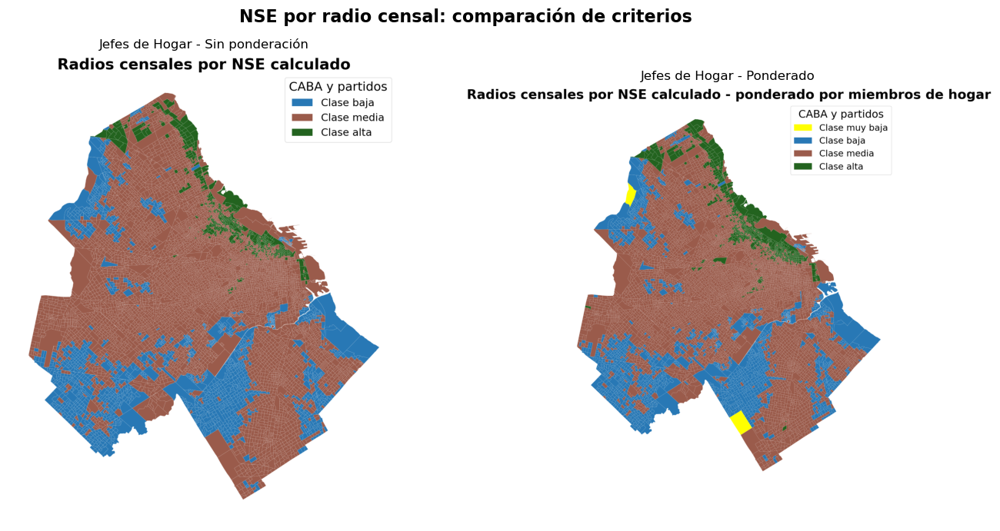

In [ ]:
NSE_radio = PILImage.open(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\RadiosCensalesNSE.png")
NSE_ponderado = PILImage.open(r"C:\Users\uzvp\OneDrive - Chevron\Documents\censo2022_trabajo\visualizations\mapa_NSE_ponderado.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(NSE_radio)
axes[0].set_title("Jefes de Hogar - Sin ponderación")
axes[0].axis("off")
axes[1].imshow(NSE_ponderado)
axes[1].set_title("Jefes de Hogar - Ponderado")
axes[1].axis("off")

plt.suptitle(r"NSE por radio censal: comparación de criterios",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

In [112]:
#Nuevo criterio con mas clases: uso MNI (Maximo Nivel de Instruccion) y armo 6 niveles.
def nse_mni_extended(mni):
    if pd.isna(mni): return np.nan
    if mni == 99: return np.nan
    if mni in [1, 2, 3]: return 1 #Sin Instruccion, Primario Completo o Incompleto -> Clase muy baja
    if mni == 4: return 2 #Secundario Incompleto -> Clase Baja
    if mni == 5: return 3 #Secundario Completo -> Clase Media-Baja
    if mni in [6, 7]: return 4 #Terciario Completo o Incompleto -> Clase Media
    if mni == 8: return 5 #Universitario Incompleto -> Clase Media Alta.
    if mni in [9, 10, 11]: return 6 #Universitario Completo, posgrado Completo o Incompleto -> Clase Alta.
    return np.nan

In [114]:
censo_data["NSE_extended"] = (censo_data["mni"].apply(nse_mni_extended))
censo_data["NSE_extended"].value_counts(dropna=False).sort_index()

NSE_extended
1.0    2196480
2.0    1391814
3.0    1359462
4.0     870158
5.0     822836
6.0     972141
NaN      50693
Name: count, dtype: int64

In [115]:
jefes_hogar_ext = censo_data.loc[censo_data["p01"] == 1].copy()
tabla_nse_jefes_ext = pd.concat([jefes_hogar_ext["NSE_extended"].value_counts(dropna=False).sort_index().rename("cantidad"),
                            jefes_hogar_ext["NSE_extended"].value_counts(dropna=False,normalize=True).sort_index().round(2).rename("porcentaje")],axis=1)
print(tabla_nse_jefes_ext)

              cantidad  porcentaje
NSE_extended                      
1.0             574818        0.19
2.0             389009        0.13
3.0             641276        0.21
4.0             450418        0.15
5.0             348182        0.11
6.0             598775        0.20
NaN              27584        0.01


In [116]:
tabla_nse_radio_ext = (jefes_hogar_ext.groupby(["codigo", "NSE_extended"],dropna=False).size().reset_index(name="hogares"))
print(tabla_nse_radio_ext.head(10))

      codigo  NSE_extended  hogares
0  020070101           1.0       17
1  020070101           2.0       14
2  020070101           3.0       21
3  020070101           4.0       19
4  020070101           5.0       13
5  020070101           6.0       19
6  020070101           NaN        3
7  020070201           1.0       48
8  020070201           2.0       76
9  020070201           3.0       49


In [ ]:
#Me fijo si hay empates.
tabla_nse_radio_ext["max_hogares"] = (tabla_nse_radio_ext.groupby("codigo")["hogares"].transform("max"))
empates_ext = (tabla_nse_radio_ext.loc[tabla_nse_radio_ext["hogares"] == tabla_nse_radio_ext["max_hogares"]].groupby("codigo").size())
print((empates_ext > 1).sum()) #Aprox 1.5% de los radios

tabla_intermedia_empates_ext = tabla_nse_radio_ext[tabla_nse_radio_ext["hogares"]==tabla_nse_radio_ext["max_hogares"]].copy()
tabla_intermedia_empates_ext["cantidad_clases_mayoritarias"] = tabla_intermedia_empates_ext.groupby("codigo")["codigo"].transform("count")
tabla_empates_ext = tabla_intermedia_empates_ext[tabla_intermedia_empates_ext["cantidad_clases_mayoritarias"] > 1]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(tabla_empates_ext.head(10))

122
         codigo  NSE_extended  hogares  max_hogares  \
868   020071016           5.0       50           50   
869   020071016           6.0       50           50   
875   020071101           5.0       78           78   
876   020071101           6.0       78           78   
1381  020071604           5.0       91           91   
1382  020071604           6.0       91           91   
1581  020071901           3.0      108          108   
1584  020071901           6.0      108          108   
1686  020072007           3.0       57           57   
1687  020072007           4.0       57           57   

      cantidad_clases_mayoritarias  
868                              2  
869                              2  
875                              2  
876                              2  
1381                             2  
1382                             2  
1581                             2  
1584                             2  
1686                             3  
1687                

In [118]:
nse_mayoritario_ext = (tabla_nse_radio_ext.sort_values(["codigo", "hogares"],ascending=[True, False]).drop_duplicates("codigo")[["codigo", "NSE_extended"]].rename(columns={"NSE_extended": "NSE_radio_ext"})) 
#Al ordenar, dentro de cada radio censal, de mayor a menor el NSE segun cantidad de hogares, y luego quedarme con el primer registro por radio, me guarda el par (codigo, NSE mayoritario)
print(nse_mayoritario_ext["NSE_radio_ext"].value_counts())

nse_pivot_ext = tabla_nse_radio_ext.pivot(index="codigo",columns="NSE_extended",values="hogares").fillna(0)
print(nse_pivot_ext.head(10))

NSE_radio_ext
6.0    3429
3.0    2654
1.0    2460
4.0     208
5.0      53
2.0      43
Name: count, dtype: int64
NSE_extended  NaN   1.0    2.0   3.0   4.0   5.0   6.0
codigo                                                
020070101     3.0  17.0   14.0  21.0  19.0  13.0  19.0
020070201     0.0  48.0   76.0  49.0  28.0  14.0  16.0
020070202     1.0  51.0   67.0  32.0  11.0   8.0   0.0
020070203     1.0  24.0   26.0  30.0  15.0   5.0   1.0
020070204     1.0  69.0   53.0  49.0  27.0   6.0   6.0
020070205     4.0  55.0   70.0  50.0  26.0  17.0   7.0
020070207     3.0  84.0  108.0  68.0  36.0  11.0   9.0
020070208     0.0  70.0   67.0  65.0  23.0  13.0  11.0
020070209     0.0  46.0   44.0  64.0  21.0  11.0   2.0
020070210     1.0  37.0   31.0  29.0  19.0   6.0   4.0


In [ ]:
jefes_hogar_ext_pond = censo_data.loc[censo_data["p01"] == 1,["codigo", "NSE_extended", "totpobh"]].copy()
tabla_nse_radio_ext_ponderada = (jefes_hogar_ext_pond.groupby(["codigo", "NSE_extended"], dropna=False)["totpobh"].sum().reset_index(name="personas"))

#Igual que antes, ordeno dentro de un mismo radio los NSE por cantidad de personas en orden descendiente, y al eliminar duplicados por codigo me quedo con la primer fila por radio, que luego del orden establecido corresponderá al NSE modal
nse_mayoritario_ext_ponderado = tabla_nse_radio_ext_ponderada.sort_values(["codigo", "personas"],ascending=[True, False]).drop_duplicates("codigo")[["codigo", "NSE_extended"]].rename(columns={"NSE_extended": "NSE_radio_ext_ponderado"})
print(nse_mayoritario_ext_ponderado["NSE_radio_ext_ponderado"].value_counts())

NSE_radio_ext_ponderado
6.0    3451
3.0    2821
1.0    2179
4.0     236
2.0     130
5.0      30
Name: count, dtype: int64


In [126]:
tabla_nse_radio_ext_ponderada["max_personas"] = (tabla_nse_radio_ext_ponderada.groupby("codigo")["personas"].transform("max"))
empates_ext_ponderado = (tabla_nse_radio_ext_ponderada.loc[tabla_nse_radio_ext_ponderada["personas"] == tabla_nse_radio_ext_ponderada["max_personas"]].groupby("codigo").size())
print("Radios empatados:", (empates_ext_ponderado > 1).sum()) #55 empates

comparacion = (nse_mayoritario_ext.merge(nse_mayoritario_ext_ponderado,on="codigo"))
comparacion["cambio"] = (comparacion["NSE_radio_ext"] != comparacion["NSE_radio_ext_ponderado"])
print(round(comparacion["cambio"].mean() * 100,2), "%")

Radios empatados: 55
8.97 %
